Cell 1(markdown) | notebook 定位

### 02 | EDA 與流失切片(M2)

**目的**：回答「誰在流失」，找出流失率顯著偏高的客群切片，產出 5–8 個候選洞察，交由 M3 檢定。
本模組支持問題定義書 §2 的決策 1(挽留資源應優先投放在哪些客群)。

**方法順序**：事前指定假設樹(下方)→ 單變數(單維度)切片 → 交叉切片 → 代理 cohort → 行為輪廓 → 匯出候選洞察。
切片為假設驅動，非事後撈取；假設樹於任何切片執行前定案(見 decision_log [M2-1])。

**資料來源**：`clean.customers`(M1 產出 ,10,127 列，基準流失率 16.07%)。
自本模組起，所有分析不再讀取 raw 層。

**判讀前提**(承接 M1 稽核結論總表)：
- 每張切片表必附各組樣本數 n；小樣本注意清單：card_category 的 Platinum(20 人)、Gold(116 人)不單獨下結論 (其小樣本類別的切片格比率易受抽樣運氣造成的隨機波動影響)。
- 資料分布右偏的欄位(credit_limit、total_trans_amt 等)分箱採等量分箱(NTILE)，不採等寬。
- 凡使用 months_on_book(tenure)之判讀，須明示與 customer_age 高度相關(0.7889)、兩者效果可能混淆。
- 樣本不含在冊未滿 13 個月的新戶，「首年早期流失」不可觀察。
- 欄位定義注意：(判讀此二欄位的切片時,要參考欄位定義的證據等級)
    - (1)avg_utilization_ratio 與兩個 chng 欄,官方未給計算公式;參考社群說法與推斷,utilization 推斷為 revolving/limit。經實際驗證後,utilization = revolving/limit 已實證成立(Cell 35.1,mismatch = 0,證據等級:已驗證),可放心判讀(參考 Cell 35.1/35.2);
    - (2)chng 欄依欄位名推斷為 Q4/Q1 比值,但因 Q4 和 Q1 的實際消費金額數值不在資料集中,無法實際驗證此推斷,證據等級維持「推斷」等級,判讀時需保守。
    - (3)README 的資料說明區將載明「兩者驗證狀態的差異」。
    - (4)撰寫 Cell 1 時,尚未「做完切片 + 列出候選洞察清單」,故僅列出(1)與(2)的推斷,並註記「若切片後發現這幾欄是核心洞察的主角,再將此驗證於 README 文件正式撰寫特定章節」。
    之後實際做完切片,發現 avg_utilization_ratio 成為候選洞察清單第3名,故在 Cell 35.1 使用 SQL 實證,最終判斷此定義成立,證據等級轉為已驗證,並回頭在此 Cell 註記第一點及第三點;
    而 total_amt_chng_q4_q1(消費變化比) 雖也列入候選洞察清單第5名,但因資料限制而無法實際驗證,也回頭在此 Cell 第二點註記原因、證據等級、判讀建議。

Cell 2(markdown) | 假設樹

### 流失假設樹(事前指定，切片前定案)

假設分四枝：枝 1–3 為行為假設(可介入，後續挽留方案可依此做設計)，枝 4 為結構假設(不可介入，用於資源分配)。<br/>
每項假設標明：對應欄位、預期的關聯方向(正相關或負相關)、驗證方式。<br/>
「不預設關聯方向是正相關或負相關」表示該假設探索性較強，現階段先不預期特定關聯方向(正相關或負相關)，此種假設在檢定階段時會採取相對保守的解讀強度。<br/>
註：
- 「解讀強度」：事前指定的假設，若有顯著結果可說「證據支持這個假設」，據此下結論；但事後看資料才注意到的差異，同樣的顯著結果只能說這是「值得後續再做驗證的」觀察，採取「解讀從嚴、只提出線索而不直接下結論」的解讀強度。
- H1 – H9 屬於事前假設，結果可直接進候選洞察清單、進 M3 檢定；次要檢視清單 (沒在假設樹先立假設) 的欄位一樣會在 M2 做切片(成本極低，順手做)。但「次要檢視清單」若有異常結果，處理流程是：標記為「事後發現(exploratory finding)」→ 記入日誌 → 判讀從嚴 → 若要進 M3 檢定，須在報告中明示其為事後發現、非事前假設。
- 不可以做的事：看到次要檢視清單某欄很顯著，就回頭默默寫進假設樹假裝是事前指定的，這就是 p-hacking (要避免)。避免發生前述問題的做法：假設樹先 commit， commit 時間在切片之前，若如前述「事後將其改寫進假設樹」，版控的 commit 時間紀錄即可證明其非事前指定。


#### 枝 1|活躍度衰退
- **H1**：近 12 個月總交易筆數越低，流失率越高(`total_trans_ct`，負相關，NTILE 五分位數)
- **H2**：近 12 個月內不活躍月數越多，流失率越高(`months_inactive_12_mon`，正相關)
- **H3**：消費金額變化比(Q4/Q1)越低，流失率越高(`total_amt_chng_q4_q1`，負相關，NTILE 五分位數)

#### 枝 2|關係深度
- **H4**：客戶與銀行往來的產品數越少，流失率越高(`total_relationship_count`，負相關)
- **H5**：信用額度動用率極低者，流失率偏高(`avg_utilization_ratio`，預期「非單調(non-monotonic)，非一路遞增或遞減」：最低分位組的流失率偏高，NTILE 五分位數)

#### 枝 3|服務摩擦 (friction)
- **H6**：近 12 個月內，與客服聯繫次數越多，流失率越高(`contacts_count_12_mon`，正相關)

#### 枝 4|人口與產品屬性
- **H7**：收入類別與流失有關聯(`income_category`，不預設關聯方向是正相關或負相關；含 Unknown 類別的流失率)
- **H8**：性別與流失有關聯(`gender`，不預設關聯方向是正相關或負相關)
- **H9**：「以 tenure 劃分的客戶生命週期階段」與流失有關聯(`months_on_book` 分箱，不預設關聯方向是正相關或負相關；
  判讀附 [M1-5] 混淆警語與倖存者偏差的方法限制，詳見代理 cohort 章節 (代理 cohort：pseudo-cohort，以「單一時點快照(橫斷面資料)」這個替代方法，模擬「世代分析 (縱向追蹤)的 客戶生命週期各階段樣貌」；這個方法有其先天限制(倖存者偏差)詳見代理 cohort 章節))

**次要檢視清單**(未立假設，切片時順帶檢視，若有異常再補充)：
education_level、dependent_count、marital_status、card_category(受到樣本數較小的限制)、customer_age、credit_limit。

In [1]:
# Cell 3 (code) | 環境設定
import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import pandas as pd
from src.db import get_engine

engine = get_engine()

# 在 M2 階段的共用常數 (本 notebook 的共用常數)：基準流失率 (所有切片的比較基準) (問題定義書 §3)
BASELINE_CHURN_PCT = 16.07

Cell 4(markdown)|階段 B 標題
## 階段 B|單變數(單維度)切片(H1–H8 + 次要檢視清單)

切法依欄位性質分三種(決策理由見 decision_log [M2-2]):
- B1 類別欄:直接分組
- B2 低基數整數欄(僅 6–7 種值):逐值分組,不分箱
- B3 連續數值欄:NTILE(5) 等量分箱,附各箱實際範圍

輸出格式統一:grp(組別)/ n(樣本數)/ churn_pct(流失率%)/ diff_pp(與基準流失率 16.07% 的差,單位:百分點)。<br/>
對應的「純 SQL 可重現版」:`sql/02_eda_slices.sql`。<br/>

### 證據支持該假設的強度級別判準

| 判定 | 條件 | 本檔實例 | 
|---|---|---|
| 強支持 | 方向命中預期 + 幅度大(diff_pp 達兩位數)+ 曲線形狀乾淨(單調或精準命中預期形狀)+ 樣本充足 | H4、H5、H6 | 
| 支持 | 方向命中預期,但幅度較小、或曲線形狀有預期外的波動 | H1(曲線形狀待查)、H2(兩端小樣本)、H3(門檻效應，非線性遞減)、H8(效果量小) |
| 弱訊號 | 有差異但幅度小(低個位數pp(約 1–4pp))、或曲線形狀無法轉為行動 | H7 | 
| 無訊號 | 全距極小,各組流失率都貼近基準流失率,此維度無區辨力(無法區分高低風險客群) | 婚姻、扶養、年齡 |

註:<br/>
(1)維度 = 用來切分客群的變數。例如: 「婚姻狀態」這個切片維度(Cell 12-14)、「卡別」這個切片維度(Cell 15-17)。<br/>
(2)「弱訊號」和「無訊號」的處置差異:無訊號(eg.婚姻)直接不深究;弱訊號(eg.income)記錄曲線形狀、留作 M5 參考,但不佔檢定名額(參附註說明第4點)


### 曲線形狀如何作為證據
判讀的對象不是單格,是整條曲線的形狀;曲線形狀本身是「判讀假設」的證據:

| 曲線形狀 | 意義 | 本檔實例 | 
|---|---|---|
| 平坦 | 各組流失率都貼著基準流失率,切片的目的(找出哪一組特別高)落空 → 無訊號 | 婚姻(全距2.09pp)、扶養 14.64–17.64%、年齡 13.72–17.37% | 
| 完整單調 | 0→6 次七個點依序遞增、無一例外 <br/>(樣本雖小但可推論非雜訊,因隨機波動的雜訊不會排出完整遞增曲線, 詳參 Cell 21) | H6 聯繫次數 |
| 門檻 | 詳參 Cell 27 | H3 | 
| 單點突出 | 僅一箱突出,其餘組別的曲線形狀無規律(對照H6完整單調,此處的單點證據力最弱,<br/>因為無「整條曲線形狀一致」的證據支持,更可能是其他因素影響力在這箱顯現,<br/>待階段 C 交叉切片驗證)(參 Cell 33 敘述) | 信用額度 |


### 附註說明:
1.洞察 (insight): 能支持商業決策的發現。本案指:發現特定客群流失率特別高,所以挽留資源該優先投放。<br/>
2.候選: M2 切片只是觀察與描述，所以目前僅是候選名單，若之後有通過「階段 C 獨立性檢視」與「M3 檢定」後，才會從候選洞察轉變為正式洞察。<br/>
3.「候選洞察」最後是否進到 M3 的判準 (透過交叉切片等方式驗證): (1)與基準流失率的差距幅度(diff_pp)夠大(若為真,值得為此投入資源行動);(2)能轉為行動(能得出一份具體名單,eg.「交易≤61筆的人」能被圈出、「等量分箱的U型兩端」難被圈出);(3)樣本夠(檢定才有意義)。<br/>
4.為什麼要篩選「進 M3 的候選洞察」而非「全部丟進 M3 做檢定」：檢定有「時間成本」 & 「多重比較問題」(每多做一個檢定,「純靠運氣猜對」的機率就持續累積;檢定做越多,假的發現越多,以上留待 M3 正式處理)。所以檢定的名額要花在「確認了就能採取行動」的訊號上。<br/>
4.1.反例:H7(income U 型, 弱訊號):只記錄,不進檢定;原因是:全距僅 3.85pp(幅度不足),且流失率偏高的兩組是收入光譜的兩端,兩群人的流失成因高機率不同,一份挽留方案無法同時打中兩群客戶,即使檢定確認差異為真,也無法轉為行動,所以不進檢定。檢定名額留給「確認了就能行動」的訊號。但還是要做記錄,理由是:(1)留下已查過但結果弱的紀錄,未來就不需要重複查,能說明為什麼不進入檢定;(2)「中等收入最穩定」這個曲線形狀是值得M5策略分配資源時的參考資訊;(3)若M4模型顯示income重要,就有紀錄能回頭對照M2查到的income資訊形狀。<br/>
4.2.為什麼 income 不進 M3 檢定, M4 模型還是會看 income: M3 是「逐個訊號的人工確認」,名額不能太多(因有「多重比較成本」),所以要篩選;M4 是把一批特徵一起丟進模型,模型自己排序每個特徵的重要性。而 income 作為一個普通特徵進模型的成本趨近零(不佔檢定名額、不會累積假發現(純靠運氣猜對的假發現)),而模型可能發現「income 單獨沒訊號,但跟別的變數組合起來有用」(交互作用:「模型抓得到、單變數(單維度)切片抓不到」的情境)。若 M4 真的顯示 income 重要,再回頭對照 M2 的紀錄(「單變數是弱 U 型」)就能推論「income 變數的重要性來自組合而非單獨」,這就是在M2留紀錄的價值。而 M3 的門檻擋的是「檢定名額」,不是「進 M4 模型的資格」。<br/>
5.候選洞察清單的排序依據:綜合判斷「diff_pp 幅度 × 覆蓋人數 × 曲線形狀清晰度 × 行動性」; M5 的挽留預算有限,要優先投入訊號最強的洞察發現。<br/>
6.H8 具備「統計顯著(男女流失率差距真實存在,不是抽樣運氣)」:因樣本數夠大,所以波動範圍受運氣影響較小,具備「統計顯著」,結果(男女流失率)的差距幾乎必然通過檢定(非抽樣運氣);H8 不具備「實務顯著(商業判斷:此差距是否值得投入資源)」:實務上2.74pp的差距是否值得投入資源挽留。M3 深入討論統計顯著 vs 實務顯著:兩種顯著要分開判斷,「通過檢定」不自動等於「要採取商業行動」,H8 的洞察價值在於「區辨統計顯著 vs 實務顯著」。

In [2]:
# Cell 5(code)|輔助函式
# 兩個輔助函式對應三種切法:B1/B2 共用 churn_by_group(), B3 用 churn_by_quintile()。
# f-string 拼欄名安全無虞:本檔案呼叫輔助函式的情境，都是直接在本檔案「hardcode 欄位名」作為參數傳入來呼叫函式;不是由外部傳入某數值作為參數，所以 SQL 指令直接用 f-string 是安全的，不需擔心 SQL Injection。

def churn_by_group(col: str, order: str = "grp") -> pd.DataFrame:
    """B1 類別欄與 B2 低基數整數欄:逐組的流失率。
    低基數整數欄慣用 order="grp" ("grp"是傳入欄位的別名,按該欄位值排序,B2 慣用,可看出逐值走勢)(預設);
    類別欄慣用 order="churn_pct DESC"(按流失率高低排,B1 慣用,流失率高的排最前面)
    """
    return pd.read_sql(f"""
        SELECT {col} AS grp, COUNT(*) AS n,
               ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
               ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
        FROM clean.customers
        GROUP BY {col}
        ORDER BY {order}
    """, engine)

def churn_by_quintile(col: str) -> pd.DataFrame:
    """B3 連續數值欄:NTILE(5) 等量分箱後的各箱流失率,bin_min/bin_max 標出各箱實際範圍。"""
    return pd.read_sql(f"""
        WITH binned AS (
            SELECT NTILE(5) OVER (ORDER BY {col}) AS quintile, {col}, is_churned
            FROM clean.customers
        )
        SELECT quintile AS grp, COUNT(*) AS n,
               ROUND(MIN({col})::numeric, 3) AS bin_min,
               ROUND(MAX({col})::numeric, 3) AS bin_max,
               ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
               ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
        FROM binned
        GROUP BY quintile
        ORDER BY quintile
    """, engine)

In [3]:
# Cell 6(code)
churn_by_group("income_category", order="churn_pct DESC")   # H7|收入類別

,grp,n,churn_pct,diff_pp
0,$120K +,727,17.33,1.26
1,Less than $40K,3561,17.19,1.12
2,Unknown,1112,16.82,0.75
3,$80K - $120K,1535,15.77,-0.30
4,$40K - $60K,1790,15.14,-0.93
5,$60K - $80K,1402,13.48,-2.59


Cell 7(markdown)
**H7 判讀**(不預設收入與流失率的關聯方向是正相關或負相關) 
- 實測:U 型:兩端($120K+ 17.33%、<$40K 17.19%)略高,中段($60K–80K)13.48% 最低;全距僅 3.85 個百分點。
- Unknown 類別 16.82%,與全體基準流失率相近:[M1-1]「保留 Unknown 類別」的決策在此順帶驗收:結果是「不願透露收入者並非特殊高風險群」(因為 Unknown 類別的流失率與基準流失率相近(16.82% vs 16.07%,僅差 0.75pp))。
- 結論:**弱訊號,不進 M3 檢定**。理由:(1)幅度不足(各組與基準流失率的差距(全距 3.85pp)太小,即使檢定確認為真,也不值得為此設計挽留動作);(2)無法轉為行動:流失率偏高的兩組是收入光譜的兩端,兩群人的流失成因高機率不同(高收入可能被更高端產品挖走、低收入可能有財務壓力),一份挽留方案無法同時打中兩群客戶,即使檢定確認差異為真,也無法轉為行動,所以不進檢定。檢定名額留給「確認了就能行動」的訊號。
- 註:幅度指「各組流失率與基準流失率的差距(diff_pp)」。
- 「中等收入最穩定」的資料分布曲線形狀留作 M5 挽留策略資源分配之參考。

In [4]:
# Cell 8(code)
churn_by_group("gender", order="churn_pct DESC")   # H8|性別

,grp,n,churn_pct,diff_pp
0,F,5358,17.36,1.29
1,M,4769,14.62,-1.45


Cell 9(markdown)
**H8 判讀**(不預設性別與流失率的關聯方向是正相關或負相關)
- 實測:女性 17.36% vs 男性 14.62%,組間差距為 2.74 個百分點;兩組樣本皆逾 4,700 人。
- 結論:證據支持「性別與流失有關聯存在」,列入候選洞察。
    - 男女之間的流失率有差是真實存在的(樣本夠大,差距非運氣的隨機波動,會通過假設檢定),性別與流失有關聯存在 → 有統計顯著; <br/>
    但因兩者流失率差距太小所以不值得行動、為此投入資源設計挽留方案 → 無實務顯著。
    - 因此,此處列入候選洞察的價值並非「設計挽留名單」,而是為了在 M3 討論「統計顯著 vs 實務顯著」的案例,屬商業判斷,檢定通過(統計顯著)不直接等同要採取行動(無實務顯著)。

In [5]:
# Cell 10(code)
churn_by_group("education_level", order="churn_pct DESC")   # 次要|教育程度

,grp,n,churn_pct,diff_pp
0,Doctorate,451,21.06,4.99
1,Post-Graduate,516,17.83,1.76
2,Unknown,1519,16.85,0.78
3,Uneducated,1487,15.94,-0.13
4,Graduate,3128,15.57,-0.50
5,High School,2013,15.20,-0.87
6,College,1013,15.20,-0.87


Cell 11(markdown)
**次要|教育程度 判讀**
- 實測:僅最高學歷端偏高:Doctorate 21.06%(+4.99 個百分點,n=451)、Post-Graduate 17.83%(+1.76);其餘四級平坦於 15.20–15.94%,貼近基準流失率。<br/>
非「學歷越高流失率越高」的整體單調趨勢,而是頂端兩級突出、且突出主體為 Doctorate (Post-Graduate 的 diff_pp 幅度僅屬弱訊號級,僅作旁證)。
- 依 [M2-1] 流程:標記為**事後發現(exploratory finding)**,主體為 Doctorate,從嚴解讀;若進 M3 檢定,報告中須明示此非事前假設。

In [6]:
# Cell 12(code)
churn_by_group("marital_status", order="churn_pct DESC")   # 次要|婚姻狀態

,grp,n,churn_pct,diff_pp
0,Unknown,749,17.22,1.15
1,Single,3943,16.94,0.87
2,Divorced,748,16.18,0.11
3,Married,4687,15.13,-0.94


Cell 13(markdown)
**次要|婚姻狀態 判讀**:因全距僅 2.09 個百分點,各組流失率皆貼近基準流失率(曲線平坦),此維度無法區分高低風險客群,無訊號,不再深究。<br/>

註:<br/>
此維度 =「婚姻狀態」這個切片維度。維度 = 用來切分客群的變數。

In [7]:
# Cell 14(code)
churn_by_group("card_category", order="churn_pct DESC")   # 次要|卡別

,grp,n,churn_pct,diff_pp
0,Platinum,20,25.00,8.93
1,Gold,116,18.10,2.03
2,Blue,9436,16.10,0.03
3,Silver,555,14.77,-1.30


Cell 15(markdown)
**次要|卡別 判讀**
- 實測:Platinum 25.00%(+8.93 個百分點)看似最高,但 n=20, 是**小樣本規則的驗證實例**:
  流失人數增減 1 人,比率即跳動 5 個百分點,此格數字不可單獨作為結論([M1 稽核 B]、判讀前提)。
- Blue 占 93.18%,此維度實質上缺乏比較力,結論:不進候選洞察
- 為何缺乏比較力:因 Blue 占 93.18%,其餘三類合計不足 7% 且皆屬小樣本,因此整個維度實際上只有Blue這一組可信,無其他可信的比較對象,此「卡別的切片」失去意義。<br/>

註:<br/>
此維度 =「卡別」這個切片維度。維度 = 用來切分客群的變數。

In [8]:
# Cell 16(code)
churn_by_group("months_inactive_12_mon")   # H2|近 12 月不活躍月數

,grp,n,churn_pct,diff_pp
0,0,29,51.72,35.65
1,1,2233,4.48,-11.59
2,2,3282,15.39,-0.68
3,3,3846,21.48,5.41
4,4,435,29.89,13.82
5,5,178,17.98,1.91
6,6,124,15.32,-0.75


Cell 17(markdown)
**H2 判讀**(預期:正相關)
- 實測:資料主體單調上升 (資料主體指「樣本量集中的中段組別」,也就是「不活躍月數 1個月 → 4個月這幾個組別」,這幾組涵蓋大多數樣本):<br/>
不活躍月數 1個月 → 4個月的流失率為 4.48% → 15.39% → 21.48% → 29.89%,支持「正相關」的假設;<br/>
列入洞察的這兩組(不活躍月數「3個月組和4個月組」) 合計 n=4281,樣本充足,可下結論。(「強調3個月和4個月組的n樣本充足」的原因: 因這兩組比基準流失率高了5.4–13.8 個百分點, 值得探索, 是候選洞察清單第6點。洞察的結論需建立在這兩組身上,所以這兩組必須樣本充足,結論才可靠。且本判讀同時排除「0個月組, 5-6個月組」這個小樣本組不解讀, 所以同時確認「未被排除、列入候選洞察的這兩組」樣本數夠充足,能下結論)
- 兩端 (0個月組, 5-6個月組)異常組「依小樣本規則標記、不解讀」:
(1)0 個月組 51.72% 反直覺(全年每月皆有動靜卻過半流失),但因 n=29 樣本數過小,易受隨機波動主導,故無針對此數值做解讀的實益;
(2)5–6 月組的流失率回落(不再沿著 1→4 的上升趨勢繼續升,反而下降), 看似趨勢反轉,但實際樣本數過小(n 僅 178 和 124),皆易受隨機波動主導,無針對此數值做解讀的實益。資料主體「正相關」的結論不受影響。
- 結論:列入候選洞察(不活躍月數是 3–4 個月的客群)。

In [9]:
# Cell 18(code)
churn_by_group("total_relationship_count")   # H4|往來產品數

,grp,n,churn_pct,diff_pp
0,1,910,25.60,9.53
1,2,1243,27.84,11.77
2,3,2305,17.35,1.28
3,4,1912,11.77,-4.30
4,5,1891,12.00,-4.07
5,6,1866,10.50,-5.57


Cell 19(markdown)
**H4 判讀**(預期:負相關)
- 實測:近乎單調: 1–2 項產品的客群流失率是 25.60% 和 27.84%, 3 項產品 17.35%,4 項產品以上壓在 10.50–12.00%;
  淺關係客群(1–2 項產品的客群,合計 n=2,153), 淺關係客群與深關係客群的流失率差距約 16 個百分點。
- 結論:強支持,列入候選洞察。商業含義:產品綁定越多、轉換成本越高、客戶黏著度越高 ➡ 流失率越低。「產品往來的深度」是防止客戶流失的結構性因素;<br/>
此處的 H4 與 H5(零動用率 = 不使用循環信用、無財務綁定者有高流失率) 是從不同角度指向同一件事:「與銀行的綁定深度」是流失的保護因子(Protective Factors)。

註:<br/>
「結構性」= 不是短期行為波動,是「客戶與銀行關係結構」帶來的長期特性。

In [10]:
# Cell 20(code)
churn_by_group("contacts_count_12_mon")   # H6|近 12 個月與客服的聯繫次數

,grp,n,churn_pct,diff_pp
0,0,399,1.75,-14.32
1,1,1499,7.20,-8.87
2,2,3227,12.49,-3.58
3,3,3380,20.15,4.08
4,4,1392,22.63,6.56
5,5,176,33.52,17.45
6,6,54,100.00,83.93


Cell 21(markdown)
**H6 判讀**(預期:正相關)
- 實測:**完整單調,全案最清晰的訊號**: 0→6 次的客群流失率(%)依序為 1.75 → 7.20 → 12.49 → 20.15 → 22.63 → 33.52 → **100%**。
- 聯繫 6 次組的客群 n=54 全數流失。單看此格雖屬小樣本,但因整條曲線階梯式上升(若是隨機波動的雜訊,七個點一路遞增的機率很低),可推論100%那格不是孤立的異常點,而是整條上升曲線的自然延伸(5次組已33.52%,6次組更高,符合趨勢)。結論:雖單格樣本小,但整條曲線的形狀補足了單格的證據力,完整論證「樣本雖小,但非雜訊」。

- 商業含義:客服聯繫次數是最明確的流失前訊號:聯繫 4 次以上(22%+)即應列入預警名單;
  反向亦成立:不只「聯繫多→高流失率」, 同時「全年 0 次聯繫者僅 1.75%」,表示「聯繫次數這個變數在光譜兩端都有區辨力」,一個變數能同時圈出預警名單和安全名單,有分析判斷價值。
- 因果方向注意:「聯繫多」與流失的關係存在兩種解釋: (a) 服務摩擦累積導致流失(前兆);(b) 決定流失者辦理註銷/爭議/餘額處理產生大量聯繫(結果)。6 次組 100% 全數流失的這個「完美」數字可能偏向解釋成 (b) 信用卡註銷流程的痕跡。因此,此「聯繫次數」變數作為風險「標記」有效(名單一樣可圈出),但作為「提前預警」的時間價值需保留(因本案資料集是快照資料,無法區分6次聯繫中哪幾次是「流失前的摩擦」哪幾次是「流失後的處理流程」),必須列入 M3/M8 的方法限制說明。
- 結論:強支持,候選洞察第一順位:第一順位的強支持綜合判斷:幅度(1.75%→100%,區辨範圍全案最大)× 曲線形狀(完整單調無例外)× 行動性(「≥4 次入預警名單」規則最簡單),這三者綜合判斷此切片是全案最強的訊號。附上「因果方向注意」,對結論敘述有所保留。<br/>

註:預警線設於 ≥4 次是工作預設值,依據有二:(1) diff_pp 自 4 次起明顯加速(+6.56 → +17.45 → +83.93),3 次組(+4.08)僅中等幅度;(2) 門檻降至 ≥3 次會使名單自 1,622 人增至 5,002 人,而 3 次組流失率 20.15% 代表該組約八成的人其實不會流失(屬誤報),挽留資源會被明顯稀釋。惟預警線的最終位置屬成本效益決策(挽留預算、單位成本、客戶價值),於 M5 正式定案,此處不視為定論。<br/>

註:信用卡實務的「爭議」= 交易爭議(dispute):客戶主張某筆帳有問題(eg.被盜刷、重複扣款、商家未出貨要求退款),向銀行申請調查與暫停付款。決定流失的客戶結清帳務時常伴隨這類帳務糾紛的爭議處理,所以這些爭議是「流失進行中」時會產生的聯繫類型之一。

In [11]:
# Cell 22(code)
churn_by_group("dependent_count")   # 次要|扶養人數

,grp,n,churn_pct,diff_pp
0,0,904,14.93,-1.14
1,1,1838,14.64,-1.43
2,2,2655,15.71,-0.36
3,3,2732,17.64,1.57
4,4,1574,16.52,0.45
5,5,424,15.09,-0.98


Cell 23(markdown)
**次要|扶養人數 判讀**:各組流失率落在 14.64–17.64% (資料分佈曲線平坦), 且皆貼近基準流失率。表示「無論扶養人數多寡,流失率幾乎無差異」,故此「扶養人數」的切片維度無區辨力,無訊號,不再深究。

In [12]:
# Cell 24(code)
churn_by_quintile("total_trans_ct")   # H1|近 12 個月交易筆數

,grp,n,bin_min,bin_max,churn_pct,diff_pp
0,1,2026,10.0,41.0,31.44,15.37
1,2,2026,41.0,61.0,37.22,21.15
2,3,2025,61.0,73.0,7.11,-8.96
3,4,2025,73.0,83.0,3.51,-12.56
4,5,2025,83.0,139.0,1.04,-15.03


Cell 25(markdown)
**H1 判讀**(預期:負相關)
- 實測:大方向支持:低活躍兩箱(≤61 筆) 的流失率是 31.44% 和 37.22%,對比最高箱(83+ 筆)流失率僅 1.04%,
  **差距逾 30 個百分點,全案最大**。
- 發生預期外的資料分布曲線形狀:**Q2(41–61 筆)的流失率高於 Q1(10–41 筆)的流失率**,表示「最低組並非最高風險」。<br/>
可能解釋:因資料集快照只拍得到「活躍水位(現在這個快照時間點刷了多少)」,拍不到「衰退方向(刷卡筆數正在增加還是正在下滑)」: Q1 混有「長期低度用卡但穩定」的小用戶(只是活躍水位低,沒有下滑趨勢,非流失前兆)(不只有「完全沒在用卡」的流失高風險用戶);Q2 則可能混有「曾經活躍、正在下滑途中」的客戶(活躍水位中等但正在下滑,已經是「正在流失中」。eg.以前刷90筆、現在掉到刷50筆)。<br/>
前述解釋在 H3 佐證(消費變化比,是全案唯一有「資料變化方向」性質的欄位): 消費下滑組(第一箱)流失率 27.2%,表示「消費下滑者確實有高流失率」。若「消費下滑者確實有高流失率」這個假設成立,則「正在下滑」比「活躍水位低」更能預警流失。此假設留待階段 E 行為輪廓驗證(比較 Q1 與 Q2 的消費變化比分布)。
- 結論:列入候選洞察(交易 ≤61 筆客群),Q2>Q1 的實際資料分布曲線形狀一併記錄。

In [13]:
# Cell 26(code)
churn_by_quintile("total_amt_chng_q4_q1")   # H3|消費金額變化比


,grp,n,bin_min,bin_max,churn_pct,diff_pp
0,1,2026,0.000,0.604,27.20,11.13
1,2,2026,0.604,0.697,12.39,-3.68
2,3,2025,0.697,0.781,12.05,-4.02
3,4,2025,0.781,0.892,13.38,-2.69
4,5,2025,0.892,3.397,15.31,-0.76


Cell 27(markdown)
**H3 判讀**(預期:負相關)
- 實測:**門檻效應**而非線性遞減: 
最低箱(變化比 <0.604,即 Q4 消費較 Q1 減少四成以上的客群) 的流失率 27.20%,
  其餘四箱流失率穩定落在 12–15%。
  方向有命中預期(變化比越低,越容易流失),但曲線形狀修正(是門檻效應,非線性)
- 商業含義:表示「消費跌破某個門檻才會觸發流失風險」, 所以若消費的小幅下滑無妨、不需擔心流失(eg.某客戶 Q1 消費十萬、Q4 剩八萬(變化比 0.8,下滑兩成):消費變化幅度的波動小,未破 0.6 門檻,不觸發流失風險;若 Q4 剩五萬(變化比 0.5,下滑五成):這個消費變化的幅度大到超過門檻,才需要示警);此資料分布曲線的形狀比線性關係更利於訂預警規則(因為線性關係下預警線切在哪都是任意的、規則沒有自然依據,門檻效應則能自然給出一條有資料背書的預警線,eg.預警線設在0.6,變化比 <0.6 即示警)。註:0.604 是五分位的箱界,不是精確的門檻位置。所以「精確臨界點」需要「更細的分箱」才能定位,現階段只能說「門檻大約在 0.6 附近」。
- 結論:支持「消費變化比越低,流失率越高」這個假設(H3),列入候選洞察。

註:<br/>
1.門檻效應(threshold effect)定義:自變數(用來預測結果的那個條件/影響因素)對結果的影響不是連續漸進,而是「跨過某個臨界值才顯現」。<br/>
2.本處用門檻效應敘述的適用性:變化比從高降到 0.6 附近,流失率幾乎不動(四箱穩定 12–15%);變化比跌破 0.6後,流失率就跳升至 27.2%,表示「影響集中在臨界值以下、臨界值之上資料分佈曲線平坦」,符合門檻效應的定義型態。<br/>

In [14]:
# Cell 28(code)
churn_by_quintile("avg_utilization_ratio")   # H5|額度動用率

,grp,n,bin_min,bin_max,churn_pct,diff_pp
0,1,2026,0.000,0.000,35.19,19.12
1,2,2026,0.000,0.100,17.57,1.50
2,3,2025,0.100,0.277,9.43,-6.64
3,4,2025,0.278,0.573,8.49,-7.58
4,5,2025,0.574,0.999,9.63,-6.44


Cell 29(markdown)
**H5 判讀**(預期:非單調,最低分位組偏高)
- 實測:**強支持且比預期極端**: 第 1 箱整箱動用率精確為 0(bin_min = bin_max = 0.000,n=2,026),流失率 35.19%;第 3–5 箱流失率僅 8.49–9.63%。
- 技術註記:零值人口超過一箱容量,溢入第 2 箱(第 2 箱 bin_min 亦為 0), 是NTILE 同值跨箱的實例,
  第 1 箱和第 2 箱邊界模糊。後續以「0 vs >0」二分切片(取代此處的五分位分箱)重驗此訊號(列入階段 C/E 待辦)。
- 商業含義:動用率 0 = 「完全未刷卡」或「有刷但每期全額繳清」(見 01_load_audit.sql [D-附錄]),此族群不使用循環信用、對信用卡的黏著度低, 與 H1(低交易筆數)、H4(與銀行關係淺)共同指向同一類客群輪廓:與銀行往來淺、無財務綁定。<br/>
- 「額度動用率低的人」屬**行為性**高風險,非財務性高風險: 這些人不是「繳不出錢」的信用風險(財務性),而是「不需要這家銀行」的流失風險(行為性)。「行為性高風險」與「財務性高風險」的區別實益: M5訂定挽留策略時,這兩種風險的應對完全不同:財務風險要控管授信(eg.刷卡總額控管、要求客戶提供擔保、定期信用覆審、延遲付款時要即時預警),行為風險要增加黏著度(eg.強化日常支付與信用卡綁定、個人化推薦與回饋、增加良好數位體驗及權益等)。
- 結論:強支持,列入候選洞察。

註:<br/>
1.循環信用:信用卡有兩種用法:(a) 每月帳單全額繳清:卡只是支付工具,客戶不欠銀行錢,銀行賺不到客戶的利息;(b) 只繳最低應繳金額、其餘欠著滾利息:這叫「使用循環信用」,欠著的卡費(本金,此處未把利息計入)就是循環欠款本金(revolving balance)。<br/>
2.額度動用率 = 循環欠款(本金) ÷ 總信用額度 (total_revolving_bal / credit_limit),所以「額度動用率」 0 = 沒欠錢 = 「根本沒刷卡」或「有刷但每期繳清」兩種人。<br/>
3.「額度動用率低的人」黏著度較低:(a)沒刷卡的人:無實質使用,隨時可能流失;(b)全額繳清的人:與銀行沒有任何財務綁定:沒有欠款要處理、沒有未繳的分期卡費綁著、沒有利息關係,換一張別家的卡成本趨近零。「額度動用率低的人」對銀行無財務依賴(無欠款、無分期、無利息關係);對照「額度動用率高的人」:正在欠銀行錢、可能有「未繳的分期卡費」,轉去其他信用卡比較麻煩,反而可能被綁住,流失率相對可能較低。

In [15]:
# Cell 30(code)
churn_by_quintile("customer_age")   # 次要|客戶年齡([M1-5] 混淆警語適用)

,grp,n,bin_min,bin_max,churn_pct,diff_pp
0,1,2026,26.0,39.0,13.72,-2.35
1,2,2026,39.0,44.0,17.37,1.30
2,3,2025,44.0,48.0,16.74,0.67
3,4,2025,48.0,53.0,15.51,-0.56
4,5,2025,53.0,73.0,16.99,0.92


Cell 31(markdown)
**次要|客戶年齡 判讀**:各箱 13.72–17.37%,資料分佈曲線平坦無訊號。
- [M1-5] 的混淆疑慮在此反而減輕 (原疑慮:因 tenure 和 age 的相關係數達 0.7889, 難區別「tenure 的訊號是「年齡效應」導致還是「年資效應」導致」):
因年齡本身就切不出差異,後續 H9(cohort) 若發現 tenure 有差異,就無立足點解釋「tenure 的差異」是「年齡效應」所致。(因為:年齡自身的切片就平坦,但若後續H9 tenure切片反而有差異, 表示「年齡效應」的解釋就失去立足點)。

- 但混淆疑慮只是「減輕」,不是「排除」:單變數(單維度)切片平坦只說明年齡的主效果(年齡單獨影響的效果)不存在,無法排除 年齡與 tenure 的交互作用(interaction:一個變數的效果大小取決於另一個變數的值,例如「短 tenure」的流失風險可能只在特定年齡層顯現。這種藏在組合裡的模式,(單維度)切片看不到;因此正式處理留待 M3/M4)。故現階段仍附註混淆警語。

- 註:
1. 「交互作用(interaction)」:兩個變數的效果不是各自獨立,而是「一個變數的效果大小,取決於另一個變數的值」。例如:假設情形是:「短 tenure 的年輕人流失率特別高、短 tenure 的年長者流失率卻不高」。做「年齡單獨切片」時,各年齡組把 tenure 的高低混在一起平均,可能會恰好抵消成一條平坦線;此時年齡(調節變數)正在調節 tenure(自變數)對流失(依變數)的效果。這種藏在組合裡的模式,單變數(單維度)切片看不到,因此曲線平坦不等於「年齡完全與tenure毫無關係」,所以現階段仍附註混淆警語。留待 M3/M4 處理。
2. 自變數 = 影響者(tenure);依變數 = 被影響的結果(流失);調節變數 = 改變「自變數→依變數效果強弱」的第三變數(年齡)。


In [16]:
# Cell 32(code)
churn_by_quintile("credit_limit")   # 次要|信用額度(資料分佈右偏 [稽核 D] + 上限34516與下限1438.3兩個特定值各有大量客戶聚集(產品規則所致)[B3-0驗證二] ) 

,grp,n,bin_min,bin_max,churn_pct,diff_pp
0,1,2026,1438.3,2307.0,22.61,6.54
1,2,2026,2308.0,3399.0,10.91,-5.16
2,3,2025,3399.0,6280.0,17.09,1.02
3,4,2025,6292.0,13565.0,15.31,-0.76
4,5,2025,13587.0,34516.0,14.42,-1.65


Cell 33(markdown)
**次要|信用額度 判讀**
- 實測:僅最低額度箱(1,438–2,307)的流失率突出(22.61%,+6.54 個百分點),其餘四箱 10.91–17.09% 無整體趨勢。
- 訊號級別:**中等訊號**<br/>
- 原因:<br/>
- (1)與基準流失率的差距中等(diff_pp 的幅度中等): 本處 diff_pp(+6.54pp) 介於強訊號(兩位數pp)和弱訊號(低個位數pp(約1–4pp))之間。<br/>
- (2)僅單點突出、無整體趨勢:只有第一箱突出,其餘四箱上下跳動無規律,無「整條曲線一致」的強證據支持,不像H4近乎單調和H6完整單調,因此證據力較弱<br/>
- (3)低信用額度族群可能與低收入高度重疊,所以「信用額度低的客戶流失率高」未必是獨立訊號,可能只是收入效應的影子;<br/>
此為業務常識(授信邏輯:收入低 → 核給額度低)推斷,無數據佐證。<br/>


- 判斷:<br/>
- (1)根據以上原因判斷,「信用額度與流失率的關係」的證據力不足以單獨列入候選洞察,可能非獨立訊號。故留待階段 C 交叉切片進一步驗證此假設的獨立性。<br/>
- (2)驗證此假設的獨立性:驗證「低信用額度的高流失率,在控制收入之後是否仍然存在」,具體做法:「交叉切片」:低信用額度 × 各收入組,若每個收入組內的低信用額度客戶的流失率都偏高,表示「信用額度有自己的效果(獨立訊號)」;若只在低收入組內偏高,表示「信用額度與流失率的關係」只是「收入效應」的影子。<br/>

In [17]:
# Cell 34(code)
# 同數值出現頻率的檢查 (total_trans_ct)|驗證 NTILE 同值跨箱的規模 
pd.read_sql("""
    SELECT total_trans_ct AS val, COUNT(*) AS n
    FROM clean.customers GROUP BY total_trans_ct ORDER BY n DESC LIMIT 5
""", engine)

,val,n
0,81,208
1,71,203
2,75,203
3,69,202
4,82,202


In [18]:
# Cell 35(code)
# 同數值出現頻率的檢查 (credit_limit)|驗證產品規則造成的大量同值聚集
pd.read_sql("""
    SELECT credit_limit AS val, COUNT(*) AS n
    FROM clean.customers GROUP BY credit_limit ORDER BY n DESC LIMIT 5
""", engine)

,val,n
0,34516.0,508
1,1438.3,507
2,9959.0,18
3,15987.0,18
4,23981.0,12


In [19]:
# Cell 35.1 (code)| 待驗證清單 #10: 驗證 avg_utilization_ratio 的定義 (計算公式)
# 前因:官方資料集未提供本欄的計算公式, H5 判讀是依賴「 = revolving_bal / credit_limit」的推斷(資料社群與推斷);現在 H5 列入候選洞察第 3 順位,符合 Cell 1 約定的「核心洞察主角」條件,所以必須升級「此欄位的定義證據等級」。
# 做法:比照稽核 [E] 的衍生欄驗證方式:實際計算「推斷的公式( = revolving_bal / credit_limit)」,並與 avg_utilization_ratio 欄位的實際數值比對後,計算 mismatch 筆數。(容差設為 0.001:因為此欄僅存三位小數,0.001 為其最小刻度(同稽核 [E] 取金額最小單位 0.01 的容差邏輯))
# 此處可進行安全除法: 因為稽核 [D] 實測 credit_limit min = 1438.3,所以確定分母不會是 0,不會發生 Division by zero 這個錯誤,不需另外做防禦處理(eg.NULLIF(credit_limit,0))。

pd.read_sql("""
    SELECT COUNT(*) AS mismatch_rows
    FROM clean.customers
    WHERE ABS(avg_utilization_ratio - total_revolving_bal::numeric / credit_limit) > 0.001
""", engine)

,mismatch_rows
0,0


Cell 35.2(markdown)
**待驗證清單 #10 的驗證判讀**:mismatch_rows = 0, 表示「全部 10,127 筆的 avg_utilization_ratio 與 revolving / limit 實際計算出的誤差值皆在 0.001 內,推斷的公式(total_revolving_bal / credit_limit)實證成立」,avg_utilization_ratio 欄位確實是由 total_revolving_bal / credit_limit 所得出。
- H5 判讀能依賴真實的計算公式(「額度動用率」確實是「欠款/額度」),做出可靠的商業解釋(額度動用率 0 = 零循環欠款 = 沒欠錢 = 未刷卡或每期都全額繳清 ➡ 無財務綁定所以黏著度低 )。
- 「Cell 1 判讀前提」與「待驗證清單 #10」已同步更新。

Cell 35.3(markdown)
**附註|若 mismatch_rows > 0 的處理路徑**(本次未觸發此情境,以下指令留存備用及筆記學習):

1. 若 mismatch_rows > 0 但極少(如個位數) → 高機率是尾數進位差,撈明細看 diff 大小,若都在 0.002 以內,放寬容差重跑並記錄。
2. 若 mismatch_rows > 0 且量大 → 欄位計算公式(定義)推斷有誤,撈明細看模式(是否為另一種公式,eg.含利息、或分母不同):這時 H5 判讀的「循環信用」整段要重新檢視。
3. 撈明細指令(「mismatch_rows > 0 但極少」或「mismatch_rows > 0 且量大」兩種情境都先跑以下指令,觀察 diff 的大小與模式):
```python
pd.read_sql("""
    SELECT clientnum, avg_utilization_ratio,
           ROUND(total_revolving_bal::numeric / credit_limit, 6) AS calc_ratio,
           ROUND(ABS(avg_utilization_ratio
                     - total_revolving_bal::numeric / credit_limit)::numeric, 6) AS diff
    FROM clean.customers
    WHERE ABS(avg_utilization_ratio - total_revolving_bal::numeric / credit_limit) > 0.001
    ORDER BY diff DESC
    LIMIT 20
""", engine)
```
(比主驗證多算兩個結果:calc_ratio = 公式實際計算出的數值、diff = 差距,並按 diff 由大到小排。最大的差距最先看,直接判斷是以下哪種情境)

- 情境 A: mismatch_rows > 0 但極少(個位數):看 diff 大小:
  - 若全部落在 0.002 以內,屬「尾數進位差」(此欄僅存三位小數,上游四捨五入與本處用 revolving/limit 實際算出的最後一位數字可能不同) 
    ➡ 放寬容差至 0.002 重跑主驗證(Cell 35.1),若 mismatch_rows 歸零則認定為「revolving/limit 此定義成立」,並記錄容差調整的理由。<br/>
  - 若個別 diff 明顯大於 0.002 → 依情境 B 的作法處理。

- 情境 B: mismatch_rows > 0 且量大:看 diff 的「模式」(稽核 [E] 也是透過 diff 模式來判斷):
  (1) diff 同方向、呈固定比例 → 真實公式可能含未知項(如分子含利息、或分母非 credit_limit) → 嘗試替代公式重新驗證;
  (2) diff 忽大忽小無規律 → 推斷的定義(計算公式)不成立 → H5 判讀中依賴此定義的商業解釋(「額度動用率 0 = 零欠款 = 無財務綁定」整段)須重新檢視, avg_utilization_ratio 欄位降級為「此欄位的定義為未知」,相關判讀從嚴。

Cell 36(markdown)
**同數值出現頻率的檢查 判讀**
- total_trans_ct 出現頻率最高的數值(81)僅 208 人,NTILE 箱界模糊度有限(跨箱同值(同值不同箱)的人數占整箱人數的比例較低),潛在誤差小, 故五分位判讀可信。
- credit_limit 出現**兩個因產品規則所造成的數值聚集**:(1)額度上限 34,516 有 508 人(驗證稽核 [D] 的推測:[D] 實測 credit_limit 的 max 剛好為
  34,516 且 [D-附錄] 推測此值為產品的額度上限(而非某位客戶剛好是此額度),當時未驗證聚集規模,經本查詢實測 508 人同值,證實此為上限值聚集);
  (2)最低額度 1,438.3 有 507 人(稽核未預期此情形,實際跑數據後補充發現):產品的「額度上限」與「最低核卡額度」都有大量客戶的同值聚集,如實反映業務規則的限制,並非資料異常。
- 額度上限數值聚集的實際原因:34,516 極可能是這家銀行核卡額度的上限(產品規則:信用條件再好的客戶,額度上限一律定在此值),所以大量「信用條件達到或超過上限標準」的客戶都拿到同一個額度值,就會看到「額度上限」這個值自然聚集大量客戶。
- 入門門檻聚集的實際原因:1,438.3 極可能是這家銀行的最低核卡額度(產品規則:新戶或信用條件剛過門檻者,一律核給最低額度),所以大量「符合最低標準」的人拿到同一個額度值,就會看到「最低核卡額度」這個值自然聚集了大量客戶。
- 為什麼這是正常的資料狀態,非資料異常:兩處聚集都是「如實反映業務規則的限制」(額度達上限的最大值聚集、符合最低門檻的最小值聚集),不是資料錯誤(如重複列、系統預設值污染)。這樣的資料如實反映了產品規則,無需清理。

Cell 37(markdown)|階段 B 小結
## 階段 B 小結

### 假設驗證總表

| 假設 | 預設關聯方向是正相關或負相關 | 實測 | 判定(實測是否支持此假設) |
|---|---|---|---|
| H1 交易筆數 | 負相關 | 低活躍兩箱 31–37%,最高活躍箱 1%;Q2>Q1 為預期外的曲線形狀 | 支持(Q2>Q1的預期外曲線形狀留待階段E檢查) |
| H2 不活躍月數 | 正相關 | 月數 1→4 流失率單調上升至 29.9%;兩端小樣本組標記 | 支持 |
| H3 消費變化比 | 負相關 | 門檻效應:<0.604 組流失率 27.2%,其餘平坦 | 支持 |
| H4 往來產品數 | 負相關 | 產品 1–2 流失率 26–28% vs 產品 4+ 項 11%,近乎單調 | 強支持 |
| H5 額度動用率 | 非單調,低段偏高 | 零動用組 35.2%,高動用組 <10% | 強支持(符合預測的「非單調+低段偏高」,diff_pp幅度大(+19.1pp),樣本足(2,026)) |
| H6 客服聯繫 | 正相關 | 次數 0→6 的流失率完整單調:1.75%→100% | 強支持 |
| H7 收入類別 | 不預設 | U 型,全距僅 3.85 個百分點 | 弱訊號,不進 M3 檢定 |
| H8 性別 | 不預設 | F 17.36% vs M 14.62%(+2.74) | 支持(因樣本數大,觀測到的「性別與流失率有關聯,差距2.74pp」這件事非運氣),<br/>但效果量小,於M3驗證(效果量(effect size):這個關聯的實際效果有多少) |


### 候選洞察清單(初稿,依訊號強度排序) 

1. [H6] [contacts_count_12_mon] 客服聯繫 ≥4 次的客群,流失率 22.6–100%,比基準流失率高 6.6–83.9 個百分點(n=1392/176/54)
2. [H1] [total_trans_ct] 近 12 個月交易次數 ≤61 筆的客群(n=4,052),流失率 31.4–37.2%,比基準流失率高 15.4–21.2 個百分點
3. [H5] [avg_utilization_ratio] 額度動用率為 0 的客群(n≥2026),流失率 35.2%,比基準流失率高 19.1 個百分點
4. [H4] [total_relationship_count] 往來產品僅 1–2 項的客群(n=2153),流失率 25.6–27.8%,比基準流失率高 9.5–11.8 個百分點
5. 消費變化比 <0.604 的客群(n=2026),流失率 27.2%,比基準流失率高 11.1 個百分點
6. 近 12 個月內不活躍 3–4 個月的客群(n=4281),流失率 21.5–29.9%,比基準流失率高 5.4–13.8 個百分點
7. 女性客群(n=5358)17.36% vs 男性 14.62%,兩者流失率差(組間差距) 2.74 個百分點(統計顯著/實務顯著之討論留待 M3)

附錄:事後發現: Doctorate 流失率 21.06%(+4.99,n=451),從嚴解讀(因為是事後發現而非事前假設);弱訊號: income U 型(記錄,不進檢定)。



### 跨假設的觀察與判讀原則

1. 洞察 2、3、4、6 同屬「低度使用/淺關係」訊號(活躍水位類:交易少、額度動用率低、往來產品少、不活躍月數多,低度使用者自然是四項全中),背後很可能是高度重疊的同一群客戶;洞察 5(消費下滑)屬「方向」訊號,與活躍水位類的重疊程度未知(下滑途中的客戶水位可能尚中等,見 H1 判讀的 Q2 討論)。
以上皆為業務邏輯推斷、未經數據驗證,待階段 C 實測。
2. 本洞察清單是「七個訊號」,不是「七群人」:
同一個客戶可能同時被多個訊號圈中(eg.一個幾乎不用卡的客戶,可能同時落入洞察 2/3/4/6 四份名單:交易少、沒欠款、只辦一個產品、常常整個月沒刷卡,一個人同時出現在四份名單上)。
尤其洞察 2–6 因背後可能是高度重疊的同一批人(如第 1 點所述),不應各自獨立解讀。若誤把各條訊號當成獨立客群(eg.把「交易 ≤61 筆(4,052 人)、動用率 0(2,026 人)、產品 1–2 項(2,153 人)、變化比 <0.604(2,026 人)、不活躍 3–4 月(4,281 人)」的情形」解讀成「五份名單、五群人、各自獨立」),實務上會發生:
(1) 高估覆蓋範圍:各名單人數加總後宣稱高風險客戶「覆蓋上萬人次」,去重後可能僅數千人;
(2) 重複編列挽留預算:同一群人被多份名單重複投入資源;
(3) 負面的客戶體驗:同一客戶被多份名單圈中,同一客戶一次收到多封挽留訊息。<br/>
名單的合併與去重,待階段 C 重疊實測後決定。
3. 各訊號(洞察 2–6 各自對應的五個訊號)的重疊程度與獨立貢獻,由階段 C 交叉切片初探、M4 模型正式處理。<br/>
重疊程度:人群交集多大:eg.額度動用率 0 的 2,026 人裡,有多少同時是交易 ≤61 筆。<br/>
獨立貢獻:已知 A 訊號後,B 訊號還能多解釋多少流失(eg.已知某客戶交易筆數少之後,再知道他額度動用率 0,這對判斷流失有沒有額外幫助)。<br/>



### 階段 C 交叉切片

1. 從階段 B 挑出四個變數做兩兩交叉(共 6 組交叉表):<br/>
(1) [H1] total_trans_ct<br/>
(2) [H5] avg_utilization_ratio(以 0 vs >0 二分,取代五分位,參 H5 註記的待辦事項)<br/>
(3) [H4] total_relationship_count<br/>
(4) [H6] contacts_count_12_mon<br/>
註:由於變數兩兩配對的組合數,會隨著變數量呈平方級(O(n^2)複雜度)成長(配對數:C的n取2 ➡ n(n-1)/2):4個變數會有6組配對、6個變數會有15組配對、100個變數會有4950組配對,為了避免「無實質分析價值的分析資訊過多」,所以只挑訊號最強的四個變數來做交叉,不做非必要的變數交叉。

2. 未入選前述四個變數的原因: months_inactive_12_mon(洞察 6)與 total_trans_ct 同屬活躍度水位,是「衡量同一面向(活躍度水位)的變數」,故取total_trans_ct 為代表(因為「衡量同一面向的變數」互相交叉所得到的資訊量低);total_amt_chng_q4_q1(洞察 5)屬「方向」類變數,其任務在階段 E (驗證 H1 的 Q1 vs Q2 假說),故不佔此處交叉切片的名額。

3. 階段 C 要驗證兩件事:
   - 活躍水位類訊號的重疊程度:四個變數兩兩交叉,實測「同一群人被多個訊號重複圈中」的規模(跨假設觀察的推斷在此驗證;未入選的洞察 5、6,其重疊性由其他變數(與洞察 5、6 衡量同一面向的其他變數)來間接推估);
   - 是否存在交叉後特別突出的組合客群(例如:「低交易 × 零動用」是否比單一條件更精準):此為 M5 挽留名單與 M4 特徵選擇提供依據。(具體做法與逐組判讀,階段 C 實作時詳述,現階段不展開)


### 待驗證事項清單(後續階段處理事項的對照)

| # | 待驗證事項 | 來源 | 為什麼要驗 | 怎麼驗 | 驗證實作階段 |
|---|---|---|---|---|---|
| 1 | H1 的 Q2>Q1 預期外形狀:「衰退方向比活躍水位更能預警」假說 | Cell 25 | 決定預警規則該抓「交易筆數少」還是「交易量正在下滑」,影響 M5 名單設計 | 比較 Q1 與 Q2 兩群的消費變化比分布,若 Q2 的變化比明顯更低,假說成立 | 階段 E |
| 2 | H5 零額度動用訊號的精確版:0 vs >0 二分重驗 | Cell 29 技術註記 | 五分位下零值人口溢箱、第 1/2 箱邊界模糊,需乾淨切法確認精確的 diff_pp 幅度 | 以 utilization = 0 / > 0 二分切片,重算流失率差距 | 階段 C |
| 3 | 活躍水位類訊號(洞察 2/3/4/6)的重疊程度 | Cell 37 跨假設觀察 | 名單去重、預算不重複編列;判斷各訊號是否為同一群人的不同面向 | 四個強變數兩兩交叉切片,實測交集規模 | 階段 C |
| 4 | 信用額度訊號的獨立性(是否為收入效應的影子) | Cell 33 | 決定「低額度」是否值得單獨列為洞察 | 低額度 × 各收入組交叉:每組內都偏高 → 獨立;僅低收入組內偏高 → 影子 | 階段 C |
| 5 | 洞察 5(方向類訊號)與活躍水位類訊號的重疊程度 | Cell 37 跨假設觀察 | 確認「下滑中」是否為獨立於「活躍水位低」的訊號 | 間接推估(階段 C)+ Q1/Q2 變化比分布(階段 E,與 #1 同一實驗) | 階段 C/E |
| 6 | H6 的因果方向注意:流失前兆 (a) vs 流失手續的痕跡 (b) | Cell 21 | 影響「聯繫次數」作為提前預警的價值;資料集為快照資料,無法根本解決此疑慮,故須誠實標注 | 無法實證,列入方法限制;M3 檢定時保留因果關係不明的敘述,M8 報告明示 | M3/M8 |
| 7 | H3 精確門檻位置(0.604 僅為箱界) | Cell 27 | M5 若採「變化比 < X 即示警」規則,X 需要更準的定位 | 對 0.4–0.8 區間做更細分箱(如十分位),觀察流失率跳升的確切位置 | 階段 E 或 M5 |
| 8 | H8 統計顯著 vs 實務顯著的正式討論 | Cell 9 | 全案「檢定通過 ≠ 該行動」的示範案例 | M3 對性別差距做檢定 + 效果量計算,並排呈現 | M3 |
| 9 | Doctorate 高流失(事後發現,非事前假設) | Cell 11 | 若進檢定,解讀強度受 [M2-1] 規範 | 若進 M3:報告明示為事後發現、非事前假設 | M3(選擇性) |
| 10 | avg_utilization_ratio 定義驗證(= revolving/limit?) | Cell 1 判讀前提 | H5 已成候選洞察第 3 順位:「核心洞察的主角」條件已觸發,定義證據等級須升級 | 比照稽核 [E]:`ABS(avg_utilization_ratio − total_revolving_bal/credit_limit)` 實際計算公式與欄位值比對,得出「容差內筆數」 | 已完成(Cell 35.1:mismatch = 0,定義實證成立;Cell 1 已寫明「驗證結果」與「判讀證據等級」) |
| 11 | 年齡 × tenure 的交互作用 | Cell 31 | 年齡主效果平坦,但不排除年齡和tenure有交互作用;H9 判讀的保留事項 | 單變數(單維度)切片無法驗證;M4 模型可納入交互項或由模型自動捕捉 | H9 判讀警語 / M4 |

Cell C-1(markdown)|階段 C 標題與旗標定義

## 階段 C|交叉切片(C1–C4)與候選洞察清單 v2

**目的**:驗證階段 B 各訊號的重疊程度與組合效應([M2-6] 兩個驗證目標),完成待驗證清單 #2/#3/#4/#5(部分),產出交付 M3 的候選洞察清單 v2。
對應之純 SQL 可重現版:`sql/02_eda_slices.sql` 階段 C 區。

**五個高風險旗標**(旗標定義(界線)全數取自階段 B 實測,定義理由見 decision_log [M2-7]):

| 旗標 | 定義 | 界線來源 | 階段 B 流失率 |
|---|---|---|---|
| low_activity 低活躍 | total_trans_ct ≤ 61 | 箱界(Q1+Q2 的上界;Q3 起流失率斷崖下降) | 31.4–37.2% |
| zero_util 零動用 | avg_utilization_ratio = 0 | 精確二分(零值溢箱之修正) | 35.19%(五分位版) |
| shallow_rel 淺關係 | total_relationship_count ≤ 2 | 依產品數量逐值分組之斷點(流失率跳升) | 25.6–27.8% |
| high_contact 高聯繫 | contacts_count_12_mon ≥ 4 | 斷點(diff_pp 自 4 次起加速跳升;此界線同時是 H6 判讀中「客服聯繫達 4 次以上即應列入流失預警名單」的工作預設值。流失預警線的最終位置屬 M5 成本效益決策) | 22.6%+ | 
| declining 消費下滑 | total_amt_chng_q4_q1 < 0.604 | 箱界(門檻效應的門檻位置);**僅參與 C3-a 的人數交集量測作為間接推估(未參與C2旗標兩兩交叉的流失率觀測),主要分析與判斷在階段 E (C3-a 只能從人數重疊做間接推估,無法回答「下滑客群與低活躍客群是否為兩種不同性質的客群」,此問題的說明見 C3-a 判讀第四點)** | 27.2% | 

注意:「階段 C 旗標界線」是由「階段 B 分位箱界」轉譯改寫成的「業務規則」,因 NTILE 同值跨箱, 所以階段C旗標人數與階段B原第一箱2,026人略有出入是正常的。(eg.零動用旗標人數是2470人, 略多於階段B分箱的第一箱2026人。因為階段B分箱時溢入第2箱的零值者,會在階段C依據零動用旗標界線被規則圈回)


**用詞約定**(三者單位都是百分點(pp),但比較對象不同,必須靠名稱區分):
| 量 | 定義 | 出現處 | 單位 |統一用詞 |
|---|---|---|---|---|
| (a) 該格流失率 − 基準流失率 16.07% | 對基準流失率的差距 | 所有切片表的 diff_pp 欄 | pp | diff_pp |
| (b) 同一子群內,旗標 true 格 − false 格 | 子群內的差距 | C2 效果分解表、C4 各收入組內比較 | pp | 組內差距 |
| (c) 兩個組別的流失率相減 | 組別之間的差距 | H8 女性 − 男性 | pp |組間差距 |

In [20]:
# Cell C-2(code)|旗標常數與交叉函式

# 旗標定義:階段 C 的單一事實來源。value 為 SQL 條件式,所有 SQL 查詢皆由此組裝。
# 旗標定義與 sql/02_eda_slices.sql 各段 CTE 相同口徑(定義/界線): 該 SQL 檔是每段 CTE 各自重複定義旗標(同一組旗標的定義,在每段查詢裡都各寫了一遍), 是純 SQL 要獨立執行的必要設計(psql 是逐段執行,無跨查詢變數)。
# notebook 則以 Python 常數把旗標定義收斂成單一事實來源,避免重複定義的漏改風險。

FLAG_DEFS = {
    "low_activity": "total_trans_ct <= 61",
    "zero_util":    "avg_utilization_ratio = 0",
    "shallow_rel":  "total_relationship_count <= 2",
    "high_contact": "contacts_count_12_mon >= 4",
    "declining":    "total_amt_chng_q4_q1 < 0.604",   # 僅參與 C3-a 人數交集量測 (主要分析判斷在階段 E) 
}
FORMAL_FLAGS = ["low_activity", "zero_util", "shallow_rel", "high_contact"]

def cross_2x2(flag_a: str, flag_b: str) -> pd.DataFrame:
    """2×2 交叉:兩旗標交叉,會得出四格(tt/tf/ft/ff)的 n / 流失率 / diff_pp,並依流失率由高到低遞減排序(最高風險格放在首位,提高可讀性)。"""
    return pd.read_sql(f"""
        WITH flags AS (
            SELECT is_churned,
                   ({FLAG_DEFS[flag_a]}) AS {flag_a},
                   ({FLAG_DEFS[flag_b]}) AS {flag_b}
            FROM clean.customers
        )
        SELECT {flag_a}, {flag_b}, COUNT(*) AS n,
               ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
               ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
        FROM flags
        GROUP BY {flag_a}, {flag_b}
        ORDER BY churn_pct DESC
    """, engine)

In [21]:
# Cell C-3(code)|C1 零動用二分重驗 (待驗證清單 #2)

pd.read_sql(f"""
    SELECT CASE WHEN avg_utilization_ratio = 0 THEN '零動用(=0)' ELSE '有動用(>0)' END AS grp,
           COUNT(*) AS n,
           ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
           ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
    FROM clean.customers
    GROUP BY 1 ORDER BY churn_pct DESC
""", engine)   

,grp,n,churn_pct,diff_pp
0,零動用(=0),2470,36.15,20.08
1,有動用(>0),7657,9.59,-6.48


Cell C-4(markdown)|C1 判讀

**C1 判讀**(待驗證清單 #2:完成)
- 實測:零動用 n=2,470、流失率 36.15%(diff_pp: +20.08);有動用 9.59%(diff_pp: −6.48),兩組差距 26.56 個百分點。
- n 由五分位版的 2,026 修正為 2,470: 因為五分位時溢入第 2 箱的 444 名零值客戶被二分重驗的規則圈回,證實 [M2-2] 「已知限制」所述的溢箱現象,亦說明「業務規則式界線」較「分位箱」更適合做「名單定義」。
- 處置:候選洞察清單 v2 起,「零動用訊號」一律引用本表數字(2,470 / 36.15% / +20.08pp)。

In [22]:
# Cell C-5(code)|C2 六組交叉(四個正式旗標兩兩交叉,共 6 組)

# 語法逐行說明:
# 1. combinations(清單, 2):由 itertools 標準函式庫提供,列出清單中「所有取 2 個元素的組合」,不重複、不計順序。FORMAL_FLAGS 有 4 個旗標,取 2 的組合共 C(4,2) = 6 組:(low_activity, zero_util)、(low_activity, shallow_rel)、...(shallow_rel, high_contact)。用它取代手寫 6 次函式呼叫。之後若旗標有增減,組合自動跟著變,不會漏寫或重複。
# 2. for a, b in ...:每一輪迴圈,combinations 給出一對旗標,解包 (unpack)成 a 與 b 兩個變數。
# 3. print(f"── {a} × {b} ──"):先印出這一組的標題,讓六張表在輸出中有明確分隔。
# 4. display(cross_2x2(a, b)):把該組交叉的 DataFrame 以 Jupyter 的格式化表格呈現。

# 為什麼用 display() 而不是 print(),也不是直接寫 cross_2x2(a, b):Jupyter 的自動顯示規則:一個 cell 只會自動渲染「最後一行頂層運算式」的結果,且此規則不適用於迴圈內部,若在迴圈裡單獨寫 cross_2x2(a, b),六張表一張都不會顯示。(頂層 = 不在迴圈/函式等縮排區塊內的最外層程式碼;運算式 = 會產生值的式子,如單獨一行的 df、1+1。迴圈內部的任何一行都不屬於頂層,故不觸發Jupyter的自動顯示規則)
# 改用 print(df):六張表都會印出,但是純文字格式,欄位對不齊、可讀性差。
# display(df):在迴圈內逐一觸發 Jupyter 的格式化渲染,六張表都以正式表格樣式呈現,就是「迴圈內要輸出多個 DataFrame」的標準做法。display 在 Jupyter 環境內建,毋須 import。

from itertools import combinations
for a, b in combinations(FORMAL_FLAGS, 2):   
    print(f"── {a} × {b} ──")
    display(cross_2x2(a, b))

── low_activity × zero_util ──


,low_activity,zero_util,n,churn_pct,diff_pp
0,True,True,1165,65.92,49.85
1,True,False,3000,21.20,5.13
2,False,True,1305,9.58,-6.49
3,False,False,4657,2.10,-13.97


── low_activity × shallow_rel ──


,low_activity,shallow_rel,n,churn_pct,diff_pp
0,True,True,547,86.29,70.22
1,True,False,3618,25.76,9.69
2,False,True,1606,6.66,-9.41
3,False,False,4356,2.66,-13.41


── low_activity × high_contact ──


...

,zero_util,shallow_rel,n,churn_pct,diff_pp
0,True,True,569,55.01,38.94
1,True,False,1901,30.51,14.44
2,False,True,1584,16.79,0.72
3,False,False,6073,7.71,-8.36


── zero_util × high_contact ──


,zero_util,high_contact,n,churn_pct,diff_pp
0,True,True,469,53.73,37.66
1,True,False,2001,32.03,15.96
2,False,True,1153,15.26,-0.81
3,False,False,6504,8.58,-7.49


── shallow_rel × high_contact ──


,shallow_rel,high_contact,n,churn_pct,diff_pp
0,True,True,157,94.90,78.83
1,True,False,1996,21.54,5.47
2,False,True,1465,19.04,2.97
3,False,False,6509,11.81,-4.26


Cell C-6(markdown)|C2 判讀

**C2 判讀**(六組交叉結果皆呈現「組合效應」;[M2-6] 驗證目標第2點)

**名詞定義(本節使用的兩個核心概念)**:
- **組合效應**(本案的操作性定義用語):兩個風險條件同時成立的客群,其流失率明顯高於「只成立其中一個條件」的客群。代表兩個條件各自帶有不同的風險資訊,同時檢視能圈出更濃縮的高風險客群。
- **交互作用(interaction effect,統計正式術語)**:「一個變數對結果的影響大小,會隨另一個變數的值而改變」的現象。本節第二部分將以實測數字呈現「淺關係、零動用、高聯繫這三個訊號對流失率的影響幅度,取決於客戶是否同時為低活躍」。這就是交互作用。


**一、組合效應全面成立**:六組交叉中,每一組的「雙真格(兩個旗標皆為 true 的客群)」流失率,都明顯高於同組兩個「單真格(只有一個旗標為 true 的客群)」。<br/>
補充:理論上可能存在「第二個條件反而圈出低風險子群」的抵消情境(此時單真格流失率會居首),但本案六組實測均未發生。舉例:「零動用 × 高聯繫」的雙真格,若多數成員是「剛辦卡所以尚未動用額度、且因不熟悉產品而多次聯繫詢問」的新客戶,其流失率可能反而低於「零動用且從不聯繫」的沉睡客戶。本案無此情形,六組皆為雙真格流失率最高。

其中三格列為**極高風險組合格**,直接進入候選洞察 v2: 

| 組合客群 | n | 流失率 | diff_pp |
|---|---|---|---|
| 淺關係 × 高聯繫 | 157 | 94.90% | +78.83 |
| 低活躍 × 淺關係 | 547 | 86.29% | +70.22 |
| 低活躍 × 零動用 | 1,165 | 65.92% | +49.85 |

「極高風險」的判定依據有三(說明:diff_pp = 流失率 − 16.07,全表減同一個固定值,因此用流失率或用 diff_pp 排序,名次完全相同;本節統一以 diff_pp 敘述,因為diff_pp 直接呈現「比基準流失率高多少」):
1. 階段 C 實測三格的 diff_pp 都很高，最低者(低活躍×零動用)也高達 +49.85,是候選洞察主力層分層門檻(+15)的三倍以上 (+15 為本案候選洞察分層的自訂門檻,選在階段 B 各訊號 diff_pp 實測值分布的相對稀疏處、取整數而定;此門檻只用於排定後續工作階段的處理順序(eg. M3 先檢定誰、M5 先看誰),至於「差異是否為真(+15 以上是真的差異、以下不是)的議題」由 M3 檢定判定,不由此門檻判定。此門檻無依據任何統計定理,只是分析者依資料分佈判斷、選一個好記的整數後,如實揭露此門檻為自訂。門檻若改成 +14 或 +16,只會影響「淺關係、不活躍」放哪一層,不影響任何結論的真偽);<br/>
2. 流失率均超過 50% :名單內「會流失的人」多於「不會流失的人」,對挽留名單而言是實質的品質差異(圈進來的人過半數真的會流失);<br/>
3. 樣本數與差距幅度(diff_pp)合併判斷:在 diff_pp 高達 +49.8 以上的情況下,這三格的樣本數(157 / 547 / 1,165)所對應的隨機波動幅度,遠不足以把流失率拉回接近基準流失率的水準,表示「這三個客群流失率極高」的結論不會被隨機波動推翻(見下方小樣本判斷說明)。


**小樣本的判斷說明(n=157 算不算小樣本)**:樣本數是否「太小」,不是一個固定數字,而是看「該樣本數下的隨機波動幅度,是否大到可能推翻結論」。
對比兩例:Platinum 格 n=20、流失率 25%(5人):流失人數增減 1 人,比率即跳動 5 個百分點,本處流失率25% 與基準流失率 16.07% 的差距(diff_pp)可能純屬波動,故不下結論;本表的淺關係×高聯繫格 n=157、流失率 94.90%(149 人):即使流失人數增減 5 人,流失率仍在 91% 以上,「此客群流失率極高」的定性結論不會因隨機波動翻盤。<br/>
註:定性結論 = 只主張方向與等級(eg.指主張「此客群流失率極高」這個等級判斷),不主張精確數值(eg.剛好是 94.90%)。<br/>

本案的操作慣例:n < 100 一律標記、不單獨下結論;n 在 100–500 之間,視差距幅度(diff_pp)決定結論強度(差距極大者可下定性結論,差距小者保守);n > 500 正常判讀。n=157 屬第二類且差距極大(+78.83),故可列入,但清單中仍附註樣本規模。<br/>
註:100/500 門檻的依據:本案自訂的操作慣例,不是統計學通用標準,依據有二:(1) 波動幅度的量級估算:n=100 時流失人數增減 1 人,比率跳動 1 個百分點,對幅度只有幾個百分點的差距足以翻盤;n=500 時增減 1 人僅 0.2 個百分點,對任何有實務意義的差距都不構成威脅;(2) 與本案既有判讀慣例一致(Platinum n=20 不解讀、Gold n=116 弱化、Doctorate n=451 可討論)。正式的定量判準(信賴區間與檢定)M3 引入後,將取代這條經驗法則。


**二、交互作用的實測呈現(本階段最重要的發現)**
以「是否低活躍」把全體客戶分成兩個子群,分別觀察三個訊號在各子群內的影響幅度。
「影響幅度(效果)」的計算方式:在同一活躍度子群內,「該訊號旗標為 true 的客群流失率」減去「該訊號旗標為 false 的客群流失率」,即該子群內的組內差距。
為什麼用組內差距衡量一個訊號的價值:一個二元旗標唯一能做的事,是把客群分成兩群;它是否有用,取決於分出來的兩群流失率差多少。若兩群流失率相同(組內差距為 0),知道旗標值對估計流失風險毫無幫助;若組內差距達 +60.5 個百分點(淺關係在低活躍子群內:25.76% vs 86.29%),知道旗標值就能把估計從 25.76% 改為 86.29%。差距越大,代表這個訊號在該子群內把高風險與較低風險客戶分得越開,也就是區分能力越強。

| 訊號 | 在低活躍子群內的效果 | 在活躍正常子群內的效果 | 兩子群效果的倍數差 |
|---|---|---|---|
| 淺關係 | 25.76% → 86.29%,差 +60.5 pp | 2.66% → 6.66%,差 +4.0 pp | 約 15 倍 |
| 零動用 | 21.20% → 65.92%,差 +44.7 pp | 2.10% → 9.58%,差 +7.5 pp | 約 6 倍 |
| 高聯繫 | 31.67% → 40.84%,差 +9.2 pp | 3.30% → 7.06%,差 +3.8 pp | 約 2.4 倍 |

表格逐欄解讀(以淺關係列為例):
- 第二欄:在「低活躍」的客戶中,淺關係者流失率 86.29%、非淺關係者 25.76% : 淺關係在這個子群內把流失率拉高了 60.5 個百分點。
- 第三欄:在「活躍正常」的客戶中,淺關係者流失率 6.66%、非淺關係者 2.66% : 同一個訊號在這個子群內只拉高 4.0 個百分點。
- 第四欄(倍數差):60.5 ÷ 4.0 ≈ 15。表示**同一個訊號,在兩個子群內的影響幅度(效果)有 15 倍之差**。

倍數差的實務意義:如果淺關係對流失的影響不受低活躍影響(即無交互作用),它在兩個子群內拉高的幅度應該差不多、倍數差應接近 1;實測三個訊號在兩個子群的影響幅度倍數是 2.4 到 15 倍,證明**三個訊號的(流失率)影響幅度都高度取決於客戶是否低活躍**,這就是交互作用存在的實測證據(由數字直接呈現,而非推測)。

總結:**淺關係、零動用、高聯繫這三個訊號單獨存在時,流失風險有限;但只要與低活躍同時出現,流失風險就大幅升高。**

反方向的觀察:低活躍旗標單獨為 true(其他訊號為 false)時,流失率為 21.2–31.7%,仍顯著高於基準流失率 16.07%。代表低活躍不依賴其他訊號、自身就具有風險影響力。統計上稱此為**主效果(main effect,正式術語)**:在同時考慮多個因素的分析中,「單一因素自身」對結果的平均影響(主效果)。主效果與交互作用是同一分析框架中互相對照的兩類效果(單一因素自身的影響 vs 因素之間相互影響)。本案結構:低活躍具有明確的主效果;其餘三訊號對流失風險的影響,主要來自與低活躍的交互作用。


**三、C2 判讀對本案後續階段的影響**:
1. **對 M5 挽留名單**:「活躍正常」子群(約 5,962 人)的所有細分格流失率(「活躍正常」子群在 C2 六張交叉表中對應的所有格子(共 12 格,流失率最高的一格為 9.58%)均低於全體基準流失率 16.07%),此子群可整體列為挽留資源的低優先對象;挽留預算應集中投放在「低活躍」子群(約 4,165 人)及其內部的高風險組合客群(C2 表列的三個極高風險組合:淺關係×高聯繫、低活躍×淺關係、低活躍×零動用)。
2. **對 M4 建模**:本節的效果分解表是「交互作用存在」的實測證據;M4 建模時應評估在模型中納入交互項(即「low_activity × 零動用」「low_activity × 淺關係」「low_activity × 高聯繫」這類由兩個變數相乘構成的特徵,用來讓模型捕捉「訊號的影響力隨低活躍與否而不同」的結構)。此事項已列入待驗證清單 #6,防止 M4 遺漏。
3. **對候選洞察清單 v2**:零動用、淺關係、高聯繫三條洞察,均加註「風險效果集中於該訊號與低活躍同時成立的子群」,提醒清單讀者不可將三者解讀為獨立於活躍度的風險因素。

In [23]:
# Cell C-7(code)|C3-a 交集矩陣 (人數) (待驗證清單 #3:四個正式旗標名單的人數重疊規模;#5 的重疊子題:下滑名單與低活躍名單重疊多少人。#5 的另一子題『兩群人性質是否不同』不在本查詢範圍,見 C3-a 判讀第四點)

pd.read_sql(f"""
    WITH flags AS (
        SELECT is_churned,
               ({FLAG_DEFS['low_activity']}) AS f_low,
               ({FLAG_DEFS['zero_util']})    AS f_zero,
               ({FLAG_DEFS['shallow_rel']})  AS f_shallow,
               ({FLAG_DEFS['high_contact']}) AS f_contact,
               ({FLAG_DEFS['declining']})    AS f_decline
        FROM clean.customers
    )
    SELECT
      SUM(f_low::int) AS n_low, 
      SUM(f_zero::int) AS n_zero,
      SUM(f_shallow::int) AS n_shallow, 
      SUM(f_contact::int) AS n_contact,
      SUM(f_decline::int) AS n_decline,
      SUM((f_low AND f_zero)::int) AS low_x_zero,
      SUM((f_low AND f_shallow)::int) AS low_x_shallow,
      SUM((f_low AND f_contact)::int) AS low_x_contact,
      SUM((f_zero AND f_shallow)::int) AS zero_x_shallow,
      SUM((f_zero AND f_contact)::int) AS zero_x_contact,
      SUM((f_shallow AND f_contact)::int) AS shallow_x_contact,
      SUM((f_decline AND f_low)::int) AS decline_x_low,
      SUM((f_decline AND f_zero)::int) AS decline_x_zero,
      SUM((f_decline AND f_shallow)::int) AS decline_x_shallow,
      SUM((f_decline AND f_contact)::int) AS decline_x_contact,
      SUM((f_low OR f_zero OR f_shallow OR f_contact)::int) AS union_any_formal
    FROM flags
""", engine)  

,n_low,n_zero,n_shallow,n_contact,n_decline,low_x_zero,low_x_shallow,low_x_contact,zero_x_shallow,zero_x_contact,shallow_x_contact,decline_x_low,decline_x_zero,decline_x_shallow,decline_x_contact,union_any_formal
0,4165,2470,2153,1622,2012,1165,547,928,569,469,157,1211,584,352,410,7292


Cell C-8(markdown)|C3-a 判讀

**C3-a 判讀**(待驗證清單 #3:完成;待驗證清單 #5 的「人數重疊」子題:完成)

**一、名單重疊規模**:四個正式旗標名單的人數合計為 10,410 人次,去除重複後實際為 7,292 人, 表示: 同一位客戶被多個旗標重複圈選的情形達 3,118 人次(約 30%)。實務意涵:編列挽留預算時,人數基準必須採用去重後的 7,292 人,而非四份名單的人次加總 10,410,否則預算會高估三成。


**二、「至少命中一個旗標」的名單不具備篩選功能**:去重後的 7,292 人已占全體客戶的 72%,挽留名單的目的是「從全體客戶中挑出較可能流失的少數人、集中投放資源」,而一份圈住四分之三客群的名單,與「不做任何挑選、對全員投放」幾乎沒有差別,挑選功能形同失效。即使預算充足,也不建議採用此名單。至少命中一旗標的名單內僅約 1,589 人會實際流失(占名單 21.8% = 1,589 ÷ 7,292)(1,589 = 全體流失者 1,627 − 命中 0 旗標層的 38 人,見 C3-b) ,意即約 78% 的挽留支出會投放在本來就不會流失的客戶身上;同樣的預算改投「命中 ≥2」名單(見 C3-b),資源會集中在流失率高出一倍以上的客群。因此,名單必須依「命中旗標的數量」進一步分層,分層結果見 C3-b。此為兩份名單(命中≥1 vs. 命中≥2)效率的對照說明,名單門檻的正式定案見待驗證清單 #9,屬 M5 決策。


**三、名單內的流失風險集中在「與低活躍重疊」的成員身上**(此為 C2 交互作用結論的另一項獨立證據):
判讀旗標名單時要分開看兩件事:「名單的成員有多少人落在低活躍名單內」與「名單圈到的流失者有多少人落在低活躍名單內」,兩者的答案可以差距極大。

以零動用名單(2,470 人)為例,兩個答案分別是:成員落在低活躍名單內的比例約 47%(1,165/2,470),流失者落在低活躍名單內的比例 86%。同一份名單,兩個問題的答案相差近 40 個百分點,判讀時若混用會誤判風險的來源:
- 名單成員的分布:與低活躍重疊者 1,165 人、不重疊者 1,305 人:成員人數約各半。
- 名單內流失者的分布:重疊側 1,165 人 × 流失率 65.92% ≈ 768 名流失者;不重疊側 1,305 人 × 9.58% ≈ 125 名:**名單圈到的流失者,86% 集中在與低活躍重疊的那一半成員身上**。(重疊側流失者 ÷ 名單全部流失者 = 768 ÷ (768 + 125) ≈ 86% = 流失者落在重疊側的占比)。

高聯繫名單以同樣方法計算,有 89% 流失者集中在與低活躍重疊的成員身上。算式:與低活躍重疊側 928 人 × 流失率 40.84% ≈ 379 名流失者 ; 不重疊側 694 人 × 流失率 7.06% ≈ 49 名流失者; (重疊側流失者 ÷ 名單全部流失者 = 379 ÷ (379 + 49) ≈ 89% = 流失者落在重疊側的占比)。

結論:零動用與高聯繫兩份名單,成員雖然約半數獨立於低活躍之外,但名單所圈到的流失風險,實質上絕大部分來自「與低活躍同時成立」的那部分成員,這與 C2 的交互作用結論相互印證。
- 選擇零動用與高聯繫展示,是因為這兩份名單的成員幾乎對半分布於低活躍內外,最能凸顯「成員分布」與「風險分布」的落差;淺關係名單成員僅 25% 落在交集,展示力較弱。所以以零動用與高聯繫展示。(淺關係名單以同方法計算,流失者落在重疊側的占比為 82% : 交集側 547 × 86.29% ≈ 472,非交集側 1,606 × 6.66% ≈ 107。472 ÷ (472 + 107) ≈ 82%,結論一致)。
- C2 與 C3-a 是兩條不同的計算路徑:C2 比較的是「子群內的流失率差距」(比率的比較),C3-a 數的是「流失者人數落在哪裡」(人數的分布)。兩條路徑互不引用對方的計算,卻指向同一個結論(風險集中於與低活躍共現處),所以互為獨立證據、相互印證。


**四、消費下滑名單與低活躍名單的重疊(待驗證清單 #5 的人數重疊子題)**:同時符合「消費下滑」與「低活躍」的客戶為 1,211 人,占消費下滑名單(2,012 人)的 60%,表示:兩份名單重疊程度高,但仍有約 800 人(40%)只符合消費下滑、不符合低活躍,代表下滑訊號沒有被低活躍訊號完全涵蓋,仍可能帶有獨立的風險資訊。
可能的獨立風險資訊舉例:eg.某客戶近 12 個月仍有 80 筆交易(未達低活躍),但消費變化比僅 0.4(消費下滑六成),表示「活躍水位仍高、但方向急跌」。這 800 人的風險若來自「衰退動能」而非「活躍水位」,下滑訊號就有機會在低活躍旗標亮起之前先行示警。這就是階段 E 要驗證的事。

待驗證清單 #5 的另一個子題:「性質問題」。說明如下,此子題依原規劃留待階段 E 處理:
- 問題內容:H1 切片發現交易筆數第 2 箱(41–61 筆)的流失率(37.22%)反而高於第 1 箱(10–41 筆,31.44%)。對此的假說是:第 1 箱含較多「長期低用量、但使用型態穩定」的客戶,第 2 箱則含較多「過去活躍、目前消費正在下滑途中」的客戶。若假說成立,兩箱雖然都叫「低活躍」,實際上是兩種不同性質的客群,風險成因不同、挽留做法也應不同。
- 為什麼階段 C 回答不了:驗證此假說需要比較兩箱客戶在「消費金額變化比」上的**完整數值分布**(兩組各 2,026 人的變化比各自呈什麼形狀、第 2 箱是否整體偏向低變化比),只比較平均數會遺漏分布形狀的差異(兩組數值各自集中在哪、偏向哪邊),而呈現分布形狀需要直方圖或箱型圖(把 2,026 人的變化比畫成直方圖後呈現的輪廓(數值集中在哪一段、偏向哪一邊、是單峰還是雙峰)),繪圖任務屬階段 E(行為輪廓)的範圍。階段 C 的工具是 SQL 的人數統計,只能回答「兩份名單重疊多少人」(量的問題:人數層面的問題:重疊多少人),回答不了「兩群人是否為不同性質的客群」(質的問題:客群性質層面的問題)。此即階段 C 與階段 E 對待驗證清單 #5 的分工。


In [24]:
# Cell C-9(code)|C3-b 旗標命中數的分層 (簡單版風險分層，不需機器學習模型做風險分層。機器學習模型價值若只比此簡單版好一點點，就要思考是否要付出更高成本使用模型)

pd.read_sql(f"""
    WITH flags AS (
        SELECT is_churned,
               ({FLAG_DEFS['low_activity']})::int + ({FLAG_DEFS['zero_util']})::int
             + ({FLAG_DEFS['shallow_rel']})::int + ({FLAG_DEFS['high_contact']})::int AS hit_count
        FROM clean.customers
    )
    SELECT hit_count AS grp, COUNT(*) AS n,
           ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
           ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
    FROM flags GROUP BY hit_count ORDER BY hit_count
""", engine)   

,grp,n,churn_pct,diff_pp
0,0,2835,1.34,-14.73
1,1,4816,8.68,-7.39
2,2,1909,36.72,20.65
3,3,492,80.49,64.42
4,4,75,98.67,82.60


Cell C-10(markdown)|C3-b 判讀

**C3-b 判讀**(簡單版風險分層,不使用機器學習模型)

**一、流失率隨命中旗標數單調且陡峭上升**:命中 0→4 個旗標,流失率依序為 1.34% → 8.68% → 36.72% → 80.49% → 98.67%,每多命中一個旗標,流失率跳升約 3–4 倍,表示:各層之間的風險差距明顯,此分層具備實際區分風險高低的能力。


**二、各層流失人數的推導與一致性核對**:每層的流失人數 = 該層人數 × 該層流失率,依序得出約 38 / 418 / 701 / 396 / 74 人。五層加總 = 1,627 人,剛好等於全體流失人數。這一步是刻意設計的核對:五層互斥且窮盡(每位客戶恰好屬於其中一層),分層流失人數加總必須能還原全體流失總數,若加總對不上,代表計算過程有誤。此處的一致性核對通過。


**三、挽留名單方案的試算**(以下數字全部由上方分層表的人數與流失率相乘、相加而得,不需任何額外查詢):
「名單方案」的意思是:以「命中旗標數達到某門檻」作為圈選挽留名單的規則。例如「命中旗標數 ≥2」方案,就是把命中 2、3、4 個旗標的三層客戶全部圈入名單。各方案試算如下(流失人數由比率推算而得,尾數有四捨五入誤差,故以「約」表示):

| 名單方案 | 名單規模 | 名單圈住的流失者 | 流失者覆蓋率 | 名單精準度 |
|---|---|---|---|---|
| 命中 ≥2 | 2,476 人 | 約 1,171 人 | 72%(1,171/1,627) | 47%(1,171/2,476) |
| 命中 ≥3 | 567 人 | 約 470 人 | 29%(470/1,627) | 83%(470/567) |
| 命中 =0(低關注名單) | 2,835 人 | 僅約 38 人 | 不適用(見下方說明) | 不適用(見下方說明) |


- **流失者覆蓋率** = 名單圈住的流失者 ÷ 全體流失者(1,627 人)。回答:「所有將流失的客戶中,這份名單圈住了幾成」。沒被圈住的部分就是漏抓。
- **名單精準度** = 名單圈住的流失者 ÷ 名單規模。回答:「名單裡的客戶,有幾成會實際流失」。其餘的部分是誤圈,即挽留成本投放在本來就不會流失的客戶身上。

- **命中 =0 那一列不計算以上這兩個指標**:該列不是挽留名單,是「低關注名單」,設計目的與這兩個指標相反。證明這 2,835 人(占全體總人數 28%)的流失率僅 1.34%,可以安全地不投入挽留資源。挽留名單的兩個指標對此低關注名單沒有意義。
- **命中 0 個旗標卻仍流失的約 38 人是否需處理**:四個正式旗標並不代表會「涵蓋所有流失原因」。客戶可能因搬遷、轉換往來銀行、他行優惠等本資料集完全沒有記錄的因素而流失,這 38 人即屬此類。本案不特別處理:此層流失率 1.34% 遠低於基準流失率,為了挽回這 38 人而把名單擴大到此層,成本效益明顯不划算;留待 M4 觀察模型是否能利用旗標以外的欄位多辨識出其中若干人,屆時與本分層比較即可。


**四、覆蓋率與精準度的取捨關係**:比較「命中旗標數 ≥2」與「命中旗標數 ≥3」兩個方案可見。把圈選門檻從「命中 3 個旗標」降低到「命中 2 個旗標」,名單變大,流失者覆蓋率從 29% 升到 72%(漏抓變少),但名單精準度從 83% 降到 47%(誤圈變多);把門檻調高則相反。**不存在讓兩個指標同時達到最高的命中旗標數門檻**。選擇哪個門檻,取決於挽留預算的多寡(名單規模 × 每人挽留成本)與漏抓一位流失客戶的代價,這是商業上的成本效益決策,於 M5 定案(已列入待驗證清單 #9)。這一組概念(覆蓋率、精準度、兩者的取捨)在 M4 評估模型時會以正式統計術語(precision / recall)與對應的量化評估方法重新引入,本節先以中文名稱與實際算式建立概念。


**五、本表對後續階段的三個意義**:
1. **確立 M4 的比較基準**:本分層沒有使用任何模型,只憑四條 SQL 條件相加,就達到「命中 ≥3 名單精準度 83%」的水準。M4 引入機器學習模型時,模型必須明顯勝過這個簡單基準(例如:在相同名單規模下取得更高的精準度),否則就沒有理由付出建模與維護的額外成本。「先建立簡單方法的成果、再要求複雜方法勝過它」是模型評估的通行做法,可避免「為了用模型而用模型」。此比較要求已列入待驗證清單 #8。
2. **M5 分層名單的第一版**:若挽留預算充足,把資源投入「命中旗標數 ≥2」的名單(2,476 人,可覆蓋 72% 的流失者);若預算緊縮,只投入「命中旗標數 ≥3」的名單(567 人,名單中 83% 會實際流失,資源浪費最少);「命中旗標數 =0」的 2,835 人流失風險極低,列為低關注即可。
3. **建立 M4 與 M5 的共同評估標準**:M4 評估模型好壞、M5 決定名單門檻,用的都是「覆蓋率 vs 精準度」這一組指標。本節先以實際數字把這組指標的計算方式與取捨關係建立起來,後續兩個模組可直接沿用,不需重新定義。

In [25]:
# Cell C-11(code)|C4 「低額度訊號」的獨立性 (待驗證清單 #4)

pd.read_sql(f"""
    WITH flags AS (
        SELECT is_churned, income_category, (credit_limit < 2307) AS low_limit
        FROM clean.customers
    )
    SELECT income_category, low_limit, COUNT(*) AS n,
           ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
           ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
    FROM flags GROUP BY income_category, low_limit
    ORDER BY income_category, low_limit DESC
""", engine)   

,income_category,low_limit,n,churn_pct,diff_pp
0,$120K +,True,17,23.53,7.46
1,$120K +,False,710,17.18,1.11
2,$40K - $60K,True,403,20.35,4.28
3,$40K - $60K,False,1387,13.63,-2.44
4,$60K - $80K,True,147,20.41,4.34
5,$60K - $80K,False,1255,12.67,-3.40
6,$80K - $120K,True,91,18.68,2.61
7,$80K - $120K,False,1444,15.58,-0.49
8,Less than $40K,True,1228,23.29,7.22
9,Less than $40K,False,2333,13.97,-2.10


Cell C-12(markdown)|C4 判讀

**C4 判讀**(待驗證清單 #4:完成)

**一、低額度訊號的獨立性驗證通過**:把客戶依收入分成六組,在每一組內部比較「低額度(額度 < 2,307)客戶」與「非低額度客戶」的流失率,六組的比較結果全部同向:低額度客戶的流失率在每一個收入組內都比較高,組內差距介於 +3.1 到 +12.9 個百分點。這個設計的邏輯是:如果「低額度流失率高」只是因為「低額度的人多半是低收入的人」(即低額度只是收入的影子),那麼把收入固定住(在同一收入組內比較)之後,低額度與非低額度之間的流失率差距應該消失;實測後流失率差距沒有消失,「影子假說」被推翻,低額度是一個與收入無關、自身就與流失有關聯的獨立訊號。
小樣本格依 C2 判讀所訂的操作慣例處理(n<100 不單獨解讀;100–500 視「組內差距幅度(同收入組的 低額度客戶流失率 vs. 非低額度客戶流失率)」決定結論強度;>500 正常判讀):「$120K+ × 低額度」(n=17)不解讀、「$80–120K × 低額度」(n=91)弱化解讀。其餘四個收入組的低額度格樣本數為 139~1,228,均可判讀,且四組的組內差距(+4.3 ~ +12.9 個百分點)全部同向。「低額度在各收入組內都偏高」的整體結論,建立在這四個可判讀的組上,不倚賴兩個小樣本格,故不受其影響。<br/>

「用組內差距幅度判斷結論強度」的原因:低額度那格只有 91 人,流失人數增減 1 人,比率就動約 1.1 個百分點。這樣 +3.10 的組內差距,只要隨機多或少了兩三個流失者就可能縮到接近 0,結論就有被推翻的可能,所以弱化解讀。反之,<$40K 組低額度格 1,228 人、組內差距 +9.32,只增減幾個人撼動不了組內差距,所以結論較穩固。<br/>

註:任何小樣本判斷都適用的原則:先確定結論比的是哪兩個數,再看樣本數會不會讓那兩個數的差距失真。


**二、關聯背後的機制尚未確定(暫不下因果結論)**:額度欄位與行為欄位的性質不同:交易筆數、聯繫次數是客戶自己的行為,信用額度則是銀行授信審查的結果(銀行核給的決定)。因此「低額度客戶流失率高」至少有兩種可能的機制:
- 機制 (a):低額度本身造成使用上的不便(額度不夠用、體驗差),因而促成流失;
- 機制 (b):低額度只是「客戶與銀行往來淺、銀行對此客戶關係的評估有限」的可見痕跡,真正驅動流失的是關係深度,額度本身不是原因。
本節的組內比較只排除了「收入」這一個混淆來源,無法區分機制 (a) 與 (b),這是觀察性資料的極限。
此兩種機制的區分有實際的商業後果:如果是機制 (b),那麼「調高額度」這個挽留手段是在處理痕跡而不是處理根本原因,會白花成本。因此 M5 設計挽留方案時,不得直接把「調高額度」列為挽留手段;「調高額度是否真的能降低流失」只有 M6 的實驗設計能夠驗證。此限制已列入待驗證清單 #11,防止 M5/M6 遺漏。

註:
(1)機制(mechanism) = 造成這個關聯的實際原因路徑。
(2)觀察性資料(observational data):分析者僅觀察記錄、未介入操控的資料;與觀察性資料相對的是「實驗資料」(隨機分組、主動介入,如 A/B 測試)。觀察性資料只能建立關聯,無法確認因果,要確認因果必須靠實驗。此即本案把因果驗證交給 M6 的原因。

**三、處置決策**(依 [M2-3] 證據強度判準,以及「預測用途與介入用途分開評估」的原則):
1. **低額度升級進候選洞察清單 v2**:在 C4 驗證之前,低額度卡在「可能只是收入的影子」的疑慮上,證據力不足以列入候選洞察;C4 的組內驗證通過後,主要疑慮被排除,證據等級依 [M2-3] 判準上升至「支持」級,應列入候選洞察清單。其單變數 diff_pp 為 +6.54,依清單分層規則屬觀察層;列入候選洞察清單的理由是它通過了獨立性驗證、可作為 M4 特徵,並標註證據型態為「控制收入後的組內比較」,這樣閱讀候選洞察清單時就知道這條洞察的證據方式與其他條目不同。
2. **低額度列入 M4 的候選特徵**:預測模型挑選特徵的標準是「與流失有穩定的關聯」(有預測力即可),不要求關聯是因果關係;而 M5/M6 設計挽留動作時,標準才是因果(動了這個因素,流失真的會降嗎)。同一個變數,在「預測誰會流失(M4)」的任務裡合格,在「靠它挽留客戶(M5)」的任務裡未必合格。兩個任務、兩套標準,分開評估、不得混用。低額度符合前者(有經過C4組內驗證的穩定關聯,此處「穩定」指:控制收入這個混淆變數後,低額度與流失的關聯仍存在,即通過第一層穩定性檢驗;更完整的穩定性(換一批樣本,關聯是否還在)由 M4 的訓練/測試切分再驗「跨樣本的穩定性」),故列入 M4 特徵;是否能作為 M5 介入手段,依上述第二大點暫不下因果結論,交給 M6。


3. **事後發現一則**:「收入 Unknown × 低額度」這一格流失率 28.06%(n=139),是本表所有格子中流失率最高的。由於 credit_limit 沒有立過事前假設(它在次要檢視清單上),且「Unknown 與低額度的組合是否能單獨拿來當作一條客群洞察」也不在 C4 這次交叉的事前目的(驗證獨立性)之內。這個發現是看結果時才注意到的,依 [M2-1] 的流程標記為事後發現、從嚴解讀;若要進 M3 檢定,報告中須明示它不是事前假設。<br/>
說明:Unknown 組的組內比較(28.06% vs 15.21%)本身是事前獨立性驗證的一部分;此處標為事後發現的,是「把 Unknown×低額度單獨列為一個高風險客群洞察」這個額外主張。事前設計只問各收入組的組內差距是否同向,未曾問哪一格的絕對水準最高。<br/>
同一格資料被用來回答了兩個不同的問題,一個是事前的、一個是事後的:
- 事前問題:「Unknown 組內,低額度者是否比非低額度者流失率高?」答案:28.06% vs 15.21%,組內差距 +12.85,同向。這個比較完全是事前驗證的一部分,它是六組同向結論中的一組,沒有任何事後成分。
- 事後發現:「『不願透露收入且低額度』這群人,是全表 12 格中流失率絕對值最高的一格,值得單獨命名為一個高風險客群」,這是另一個主張。事前設計只問「各組內差距是否同向」,從沒問過「哪一格絕對水準最高、能否獨立成為一個客群洞察」;後者是看到數字後才新出現的念頭。

Cell C-13(markdown)|C5 階段 C 小結
## 階段 C 小結

### 候選洞察清單 v2 (交付 M3 假設檢定;依 diff_pp 幅度分層排序,每條標註證據型態) 
- 依 diff_pp 幅度排序的原因: (1) diff_pp 直接代表「比基準高多少個百分點」,是商業影響幅度的第一順位指標;(2) M3 的檢定名額有限([M2-1]),清單依幅度排序,讓 M3 從「若確認為真、最值得行動」的洞察開始消耗名額。
- 三層的定義與處置:主力層(diff_pp ≥ +15):M3 優先檢定,M4 特徵與 M5 名單設計的核心依據;中段層(+9 ~ +14):進 M3 檢定,順位次於主力層;觀察層(diff_pp 幅度未達中段門檻、但有特定保留價值):不作為行動依據,保留原因個別註明(eg. 性別留作 M3 統計顯著與實務顯著分離的討論案例)。
- 排序邏輯:分層(主力/中段/觀察)嚴格依 diff_pp 門檻;層內排序則是幅度 × 樣本規模 × 證據完整度的綜合判斷。

本清單是階段 B(單變數切片)與階段 C(交叉切片)全部發現的收斂結果,取代階段 B 小結的 v1 清單。
與 v1 的差異:新增第 1、2 條(階段 C 產出)、第 3 條改用 C1 精確版數字、第 9 條 低額度為新增條目(觀察層)、第 5/6 條加註交互作用條件。

**主力層(diff_pp +15 以上)**

| # | 洞察 | 關鍵數字 | 證據型態與附註 |
|---|---|---|---|
| 1 | 命中旗標數風險分層 | 命中 0→4 個旗標,流失率 1.34%→98.67%,完整單調上升 | 四個正式旗標命中數加總的分層(五層互斥且窮盡,流失人數加總經一致性核對還原總數);此分層是 M4 模型的比較基準、M5 分層名單的第一版 |
| 2 | 極高風險組合客群 | 淺關係×高聯繫 94.90%(n=157);低活躍×淺關係 86.29%(n=547);低活躍×零動用 65.92%(n=1,165) | 2×2 交叉的雙真格;n=157 落在樣本數操作慣例的 100–500 區間,因 diff_pp 幅度極大仍可下定性結論,判讀時附樣本規模說明 |
| 3 | 零動用 | 流失率 36.15%(n=2470;diff_pp +20.08;C1 二分精確版) | 二分切片(取代五分位版數字);風險效果集中於「與低活躍同時成立」的子群(交互作用,見 C2 判讀) |
| 4 | 低活躍(交易 ≤61 筆) | 流失率 31.4–37.2% (n=4165,依旗標規則 ≤61 筆計;較階段 B 五分位的 4,052 略多,原因同 C1:同值跨箱者被規則圈回) | 唯一具明確主效果的訊號(單獨成立時流失率仍顯著高於基準流失率);Q2>Q1 的形狀問題留待階段 E 驗證 |
| 5 | 高聯繫(≥4 次) | 流失率隨聯繫次數遞增:22.6%(4 次)→ 100%(6 次) | 進 M3 檢定(原因:事前假設 H6);排在主力層最末位(原因:主力段4次組diff_pp僅+6.56、雖高次數組diff_pp幅度極大但樣本小176、54,綜合diff_pp幅度與樣本規模後,排在主力層最末位);單獨成立(客戶活躍正常)時流失率僅 7.06%(此限制與#3零動用、#6淺關係相同);另定位為風險標記而非提前預警([M2-5]);預警線位置(≥4)為工作預設值,最終位置屬 M5 成本效益決策 |


**中段層(diff_pp +9~+14)**

| # | 洞察 | 關鍵數字 | 證據型態與附註 |
|---|---|---|---|
| 6 | 淺關係(1–2 項產品) | 流失率 25.6–27.8%(n=2,153) | 風險效果集中於「與低活躍同時成立」的子群(交互作用,見 C2 判讀) |
| 7 | 消費下滑(變化比 <0.604) | 流失率 27.2%(n=2,012) | 與低活躍名單重疊 60%,但仍有 40% 成員獨立於低活躍之外;是否為獨立性質的訊號(質的問題)留待階段 E 分布比較 |
| 8 | 不活躍 3–4 個月(H2) | 流失率 21.5–29.9%(n=4,281) | 與低活躍同屬活躍度面向,兩者高度相關;M3 檢定與 M4 特徵選擇時須注意兩者的相關性,擇一作為代表或並列比較,不可當成兩條獨立證據: total_trans_ct(交易筆數:低活躍旗標定義) vs. months_inactive_12_mon(不活躍月數) |


**觀察層**

| # | 洞察 | 關鍵數字 | 附註 |
|---|---|---|---|
| 9 | 低額度(<2,307) | 單變數(credit_limit)的流失率 22.61% (diff_pp +6.54);控制收入後各組內的(低額度vs非低額度)的組內差距 +3.1~+12.9 | 單變數 diff_pp +6.54,未達中段層門檻,依規則列觀察層。保留價值:C4 控制收入後驗證為獨立訊號,列入 M4 候選特徵;機制未定(額度造成使用不便 vs 額度只是關係深度的痕跡),不得直接作為挽留手段(待驗證清單 #11) |
| 10 | 性別 | 女性流失率 17.36% vs 男性流失率 14.62%(兩組的組間差距為 +2.74 個百分點) | 樣本極大、組間差距偏小(男性與女性這兩組的流失率之間的差距只有 2.74 pp),預定作為 M3「統計顯著與實務顯著分離」的討論案例 |


**事後發現附錄**(從嚴解讀;若進 M3 檢定,報告須明示非事前假設):
- Doctorate 流失率 21.06%(diff_pp +4.99,n=451);
- 收入 Unknown × 低額度 流失率 28.06%(n=139)。

**已檢視但不進檢定的紀錄**(留下「查過了、結果是訊號弱」的證據,避免重複查證):
income 呈 U 型但全距僅 3.85 個百分點(弱訊號,[M2-3]);marital / dependent / age 曲線平坦(無訊號)。

### 待驗證事項清單更新(#1–#5 為既有事項,#6 起為階段 C 新增) (本表為階段 C 收尾時的版本，M2 定版清單見 Cell E-9)

| # | 事項 | 狀態 |
|---|---|---|
| 1 | H1 的 Q2>Q1 形狀假說(次低箱為何比最低箱更高風險、流失率更高) |  ✅ 完成(E1:Q1/Q2 消費變化比分布高度重疊,中位數 0.694 vs 0.738,原假說被推翻;Q2>Q1 之成因列為原因未明) |
| 2 | 零動用訊號的精確 diff_pp 幅度 | ✅ 完成(C1:n=2,470、流失率 36.15%) |
| 3 | 四個旗標名單的人數重疊規模 | ✅ 完成(C3-a:重複 30%,聯集占全體 72%) |
| 4 | 低額度是否為收入的影子 | ✅ 完成(C4:組內驗證通過,低額度為獨立訊號) |
| 5 | 消費下滑與低活躍的重疊/性質 | ✅ 完成(C3-a:人數重疊 60%;E1:Q1/Q2 為同一性質客群,不需分開處理) |

**階段 C 新增待辦**(後續階段的待辦事項新增,防止遺漏):

| 新# | 事項 | 交辦階段 | 依據 |
|---|---|---|---|
| 6 | 建模時評估納入交互項(low_activity 分別乘上零動用/淺關係/高聯繫) | M4 | C2 效果分解:同一訊號在兩子群內的效果相差 2.4–15 倍 |
| 7 | 檢查旗標特徵之間的相關性對迴歸係數穩定性的影響(高共現在 M4 轉化為共線性議題) | M4 | 共線性:兩個高度相關的變數放入同一個迴歸模型,模型難以分辨影響該歸給誰,係數估計因而不穩定;由 C3-a 實測的高度重疊可預期「旗標轉為模型特徵後彼此高度相關」,此議題於 M4 處理 |
| 8 | M4 模型評估報告必須附上與 C3-b 簡單分層基準的成績比較 | M4 | C3-b 意義 1:模型須勝過簡單基準才有引入的理由 |
| 9 | 挽留名單門檻(選擇命中旗標數 ≥2 名單 或 ≥3 名單)依預算與成本效益定案 | M5 | C3-b 試算:覆蓋率與精準度的取捨無法兩全 |
| 10 | 高聯繫預警線位置(現為 ≥4 次的工作預設值)依成本效益定案 | M5 | H6 判讀註、[M2-5] |
| 11 | 「調高額度」不得直接列為挽留手段;若要採用,須經實驗驗證(機制 (a)(b) 未定) | M5 / M6 | C4 暫不下因果結論 |
| 12 | 事後發現二則(Doctorate、Unknown×低額度)是否進 M3 檢定,於 M3 開工時決定 | M3 | [M2-1] 事後發現處理流程 |
| 13 | mart 層匯出:依 M8 儀表板設計定案後,再一次匯出 data/processed/ 的 CSV | M8 | [M2-13] |
| 14 | Excel 樞紐分析重現:以樞紐表重現一張儀表板選用的切片,驗證與 SQL 數字一致,產出 churn_pivot_summary.xlsx 並於 README 技術棧列入 Excel | M8 | [M2-14] |



### 與後續階段的銜接

- **階段 D(代理 cohort)**:以 months_on_book 分箱繪製流失率隨在冊月數變化的曲線;判讀必須附上兩項方法限制: (1)tenure 與年齡相關 0.7889 的混淆警語([M1-5]),以及 (2) 單一時點快照造成的倖存者偏差。
- **階段 E(行為輪廓)**:兩項任務:(1) H1 的 Q1/Q2 兩組客戶(交易筆數最低箱 10–41 筆與次低箱 41–61 筆) 在消費變化比上的分布比較(回答待驗證清單 #1 與 #5 的性質問題);(2) 流失組與留存組在重點行為特徵上的分布圖。階段 E 是 M2 唯一使用 Python 繪圖的階段。

Cell D-1(markdown)

## 階段 D|代理 cohort(H9)

**目的**:以在冊月數(tenure)依年段分箱,檢視客戶生命週期各階段的流失率,驗證 H9(假設樹最後一條)。
**分箱決策**:年段(13–24 / 25–36 / 37–48 / 49–56,第四箱僅 8 個月,因資料 max=56),不用 NTILE:年段是客戶生命週期的業務語言(客戶與銀行往來第 2/3/4/5 年),銀行看 tenure 是按年看,供決策者直接判讀([M2-11])。(「NTILE 第三分位」這樣的寫法對業務需求的讀者無意義)
**方法定位**:本資料為單一時點快照,此為代理 cohort(pseudo-cohort),非真實世代追蹤:以「不同 tenure 客戶在同一時點的狀態」模擬「同一批客戶隨時間的變化」:以「單一時點快照(橫斷面資料)」這個替代方法,模擬「世代分析 (縱向追蹤)的 客戶生命週期各階段樣貌」
**方法限制三項**:1.倖存者偏差、2.tenure × age 混淆、3.無新戶,說明請見本節末段。

對應之純 SQL 可重現版:`sql/03_cohort.sql`。

In [26]:
# Cell D-2(code)
# D1 | H9 : 依年段分箱,各年段的流失率
pd.read_sql(f"""
    SELECT CASE
             WHEN months_on_book BETWEEN 13 AND 24 THEN '13-24(第2年)'
             WHEN months_on_book BETWEEN 25 AND 36 THEN '25-36(第3年)'
             WHEN months_on_book BETWEEN 37 AND 48 THEN '37-48(第4年)'
             ELSE '49-56(第5年)'
           END AS tenure_band,
           COUNT(*) AS n,
           ROUND(100.0 * AVG(is_churned::int), 2) AS churn_pct,
           ROUND(100.0 * AVG(is_churned::int) - {BASELINE_CHURN_PCT}, 2) AS diff_pp
    FROM clean.customers
    GROUP BY 1
    ORDER BY MIN(months_on_book)
""", engine)   

,tenure_band,n,churn_pct,diff_pp
0,13-24(第2年),847,14.88,-1.19
1,25-36(第3年),5418,16.08,0.01
2,37-48(第4年),3207,16.18,0.11
3,49-56(第5年),655,16.95,0.88


In [27]:
# Cell D-3(code)
# [D1-補] 單值出現頻率的檢查:列出「在冊月數」人數最多的前 5 個單值。因四箱人數懸殊,確認是否存在單值集中。
pd.read_sql("""
    SELECT months_on_book AS val, COUNT(*) AS n
    FROM clean.customers
    GROUP BY months_on_book ORDER BY n DESC LIMIT 5
""", engine)

,val,n
0,36,2463
1,37,358
2,34,353
3,38,347
4,39,341


Cell D-4(markdown)|判讀

**H9 判讀**(H9 假設「以 tenure 劃分的客戶生命週期階段」與流失有關聯。不預設關聯方向是正相關或負相關)
- 實測:四箱流失率 14.88% / 16.08% / 16.18% / 16.95%,diff_pp 介於 −1.19 ~ +0.88,全距僅 2.07 個百分點,全數貼近基準流失率;
另 tenure=36 單值集中 2,463 人(佔 25–36 箱 45%,成因無法由本資料判定,列為資料特徵,詳細說明見 sql/03_cohort.sql [D1-補])。
- 判定:**無訊號**: 全距在此樣本規模下不足以構成差異,且與 customer_age 切片同樣平坦(13.7–17.4%)的結果一致;因曲線平坦無訊號,故 H9 不成立,不進候選洞察清單。
- 補充:age 和 tenure 分別實測都平坦,兩個單變數各自都無訊號。切片判讀上, 解除了「tenure 訊號其實是年齡效應」的切片層混淆疑慮,因兩者皆無單變數訊號,不進洞察清單。
但 M4 模型層的共線處置照舊([M1-5] 二擇一),因兩個高度相關的變數放進同一個迴歸,係數依然會不穩(與此處「各自有無單變數訊號」的結論無關)。M4 時需處理共線問題。
(「兩者皆無單變數訊號」表示「單獨看這個變數,分不出流失率高低的客群」,但不能直接斷定「對預測毫無影響」。因為變數可能對模型仍有提升預測能力的意義,在模型裡可能還有用:因為模型是多變數一起看,所以一個變數可能「單獨沒用、但和其他變數搭配時能提供一點資訊」)。

- 對決策的意涵:H9 補上 M2 驗證的最後一塊: 本資料中,可辨識流失風險的訊號全部集中在行為面(枝 1–3 六條假設全數獲支持),屬性面(收入、性別、年資、年齡)幾乎全平。兩個後果:(1) M8 敘事可據此把重點正當地放在行為訊號,屬性面以「已檢視、無訊號」一句交代;(2) 挽留資源依行為旗標分層即可,不需按 tenure 設計不同方案。注意:此為「訊號在哪」的描述,行為與流失的因果方向仍未定([M2-5]),不能直接寫成「流失由行為造成」。

- 待辦:「tenure=36 聚集」於階段 E / M8 任何以 tenure 為軸的圖須加註「已知資料特徵」;M4 若考慮將 tenure 列為特徵,需參考其有效區分力偏低的這個「已知資料特徵紀錄」(細節參 03_cohort.sql 的底部註解二)([M1-5] M4 的二擇一處置不變)。


- 附:M2 階段的假設驗證結果總覽:(完整版,補入 H9;階段 B 小結的總表為 H1–H8 在該階段當下的紀錄,不需回頭修改)

| 類別 | 假設 | 結果 |
|---|---|---|
| 行為(枝 1–3) | H1 交易筆數、H2 不活躍、H3 消費下滑、H4 產品數、H5 動用率、H6 聯繫 | 六條全數獲支持,diff_pp 最高到 +21 | 
| 屬性(枝 4) | H7 收入 | 弱訊號 | 
| 屬性(枝 4) | H8 性別 | 有關聯但兩組的組間差距小(+2.74個百分點) (有關聯的意思是:確實不同性別的流失率不同,所以「性別與流失確實有關聯」(不像婚姻狀態變數切片時是每一組流失率都貼著基準流失率這樣的毫無訊號、毫無關聯),只是組間差距只有 2.74pp, 有差距但不多,不值得為此設計挽留策略,這就是 M3 討論的「統計顯著 vs 實務顯著」) | 
| 屬性(枝 4) | H9 tenure | 無訊號(本節) | 
| 屬性(次要) | age、婚姻、扶養 | 無訊號 |

Cell D-5(markdown)|方法限制

### 代理 cohort 的三項方法限制(此三項為方法本身的限制,與 H9 的驗證結果無關,無論驗出有無訊號皆須揭露)

1. **倖存者偏差**:
   真實的世代分析(cohort) 必須追蹤「同一批客戶隨時間經過」的流失率觀察,但因本資料集為單一時點快照,所以方法上有所限制,只能採用「代理cohort(代理的世代分析)」,以「單一時點快照(橫斷面資料)」這個替代方法,模擬「世代分析 (縱向追蹤)的 客戶生命週期各階段樣貌」。
   實例說明: tenure(在冊月數)較長的箱(如 49–56 箱, 在冊已超過四年),其成員是「撐過前四年都未流失」的篩選結果。若該箱流失率偏低,低流失率有一部分是篩選的結果 (會走的人早就走了,留下來的本來就是不易流失的人) 而非 tenure 的保護效果 (保護效果:指「在冊時間本身使客戶更不易流失」的因果性影響,例如:待久了累積的習慣與轉換成本,使客戶越不想離開)。「篩選效果」與「保護效果」在快照資料中的表象相同,無法區分。
2. **tenure × age 混淆**([M1-5]):
   兩者相關係數 0.7889。本案 age 切片已實測曲線為平坦,降低「tenure 訊號實為年齡效應」的疑慮;但此僅解除切片層的混淆疑慮,M4 模型層的共線處置(二擇一)不變 (細節說明可見 Cell D-4 判讀)。
3. **無新戶**:
   tenure 最小值為 13,「首年流失」(業界公認的高風險期)完全無法觀察，這是資料集的先天限制。故本曲線只描述「已在冊滿一年者」的生命週期,不能將本曲線的結論套用到觀察範圍外的新戶身上。
   註:不能將本曲線結論外推至新戶。外推 (extrapolate) :把「在某個範圍內觀察到的結論」套用到「觀察範圍之外」。

註:<br/>
這三項限制是方法本身(用單一時點快照做代理 cohort)的限制,不是結果的限制。所以無論 H9 驗出來是有訊號還是無訊號,三項限制都一樣存在、必須揭露。<br/>
預防誤解:「H9 都判無訊號了,方法限制還重要嗎?」此處的方法限制仍重要。<br/>
舉例:<br/>
1.實測曲線平坦: <br/>
倖存者偏差的作用方向是「讓長 tenure 箱的流失率看起來偏低」。「實測曲線 = 真實的 tenure 效果 + 倖存者偏差的下拉力」,但我們實測的曲線是平的,此結果反推可知:能產生平坦曲線的組合只有兩種:(a) 實測曲線平坦 = 兩個大小相當、方向相反(+5 + −5 = 0) :真實效果其實是「tenure 越長越容易流失」(與倖存者偏差作用方向相反),恰好被偏差的下拉力抵銷,最後呈現平坦曲線; 或 (b) 實測曲線平坦 = 兩個都 ≈ 0(0 + 0 = 0): tenure 幾乎無真實效果,偏差力也幾乎等於零。<br/>
2.(a)、(b)兩種情境都指向同一個結論:「tenure 越長越不流失」這個方向的真實效果不存在(我們原本假設的方向不成立)。因為若此真實效果存在,應該要測出「曲線下斜(因最後一箱流失率偏低) + 偏差是同方向的下拉力」,曲線應該更明顯下斜。但本案實測就是平坦曲線,所以「tenure 越長越不流失」才會被排除。<br/>
3.釐清:判定 H9(tenure 與流失有關聯,不預設關聯方向)無訊號的直接依據是「實測曲線平坦」;上述偏差方向推理是額外的檢查,是為了確認:即使考慮倖存者偏差,「無訊號」這個判定也不會改變。<br/>
4.另外,若當初真的實測出「長 tenure 流失率低」,這樣的訊號就必須先扣掉倖存者偏差才能解讀(實務作法:拿有時間戳的歷史資料做真世代分析、使用統計上的存活分析,但這兩個做法都需要知道每個客戶的觀察起點,本資料集沒有這樣的資料,所以只能用此處方式:明文揭露偏差的存在與作用方向,並依方向調整結論的保守程度)。<br/>

兩種結果下,讀者都需要知道這三項限制才能正確理解曲線的含義,所以無論 H9 驗證結果如何, 都要揭露這三項方法限制。

Cell E-1(markdown)

## 階段 E|行為輪廓(M2 最後一個階段,Python 繪圖)

**目的**:以分布圖回答切片表回答不了的「性質問題 (交易筆數最低箱 10–41 筆與次低箱 41–61 筆,是否為兩種不同性質的客群)」:<br/>
問題:為什麼 total_trans_ct 次低箱的流失率比最低箱的流失率還高。<br/>

選欄的思考脈絡:階段 E 三張圖各有不同的角色:<br/>
1. E1 屬「驗證」:以分布比較回答階段 B 遺留的形狀問題(Q1/Q2 是否為兩種不同性質的客群,待驗證清單 #1/#5)。<br/>
2. E2 屬「呈現行為輪廓」:行為輪廓需要一張最能代表「流失客戶長什麼樣」的圖,故選全案區分力最強的變數(交易筆數,H1)。<br/>
3. E3 屬「確認分布形狀」:M3 選擇哪種檢定方法,必須依賴「分布形狀」作為證據,E3 畫圖是為 M3 的方法選擇先做視覺確認 (同時兼作行為輪廓的第二張圖,如工作細項表中的動機欄位)。<br/>
   (1) total_trans_amt 的右偏屬性,已於 M1 稽核 [D] 時以數字判定(平均數遠大於中位數), M3 依據 M1 稽核 D 的證據(資料右偏),規劃對此欄採「非參數檢定」; <br/>
   (2) E3 則在進入 M3 檢定前, 先把「M1 數字級的判定」以箱型圖的完整分布做視覺化確認,用圖確認「total_trans_amt 確實是右偏形狀」,並留作 M3/M8 的佐證圖。<br/>

**通則**:先有形狀證據(統計量或分布圖皆可),再選檢定方法。本案的順序符合此原則: M1 數字證據(右偏) → 規劃 M3 方法(total_trans_amt 是「連續數值的兩組比較」且已知右偏,選擇非參數的 Mann-Whitney。) → 實際進入 M3 前, 在 E3 畫圖做視覺確認。<br/>

**註**:為什麼資料右偏就要用「非參數檢定」(此處說明概念, 細節留到 M3 說明):<br/>
檢定方法主要有兩種:<br/>
1. 參數檢定(如常見的 t 檢定)的運作方式是「先假設資料服從某種特定分布(通常是常態分布:左右對稱的鐘形)」,然後在這個假設之上比較兩組的平均數;假設成立時,這種方法最有效,但資料若明顯不符合假設(例如嚴重右偏),會出現兩個問題:(1) 它用來比較的「平均數」,已被右偏的高值拉離多數人的實際情況(如 E3 圖呈現),(2)且建立在錯誤分布假設上的結論,可信度降低。<br/>
2. 非參數檢定(如 Mann-Whitney)則「不假設資料服從任何特定分布」,「非參數」的意思就是「不依賴分布參數的假設」;這種方法把數值轉成名次後再比較,右偏、離群值都影響不了名次,所以資料偏斜的事實不影響此檢定的可信度。
3. 兩種檢定方法的取捨:資料接近常態分佈時,參數檢定較靈敏;資料明顯偏斜時,非參數檢定較可靠。因本欄(total_trans_amt)資料右偏已由稽核 [D] 判定,故在 M3 針對此欄位的檢定方法會選擇「非參數檢定」。<br/>


**方法**:切片表比較的是各組的單一數字(流失率),本節比較的是各組的完整數值分布:分布的形狀(集中在哪、偏向哪邊)才能回答「兩群人是不是不同性質的人」。

**圖表文字採英文**(標題、軸標、圖例),判讀以中文寫於 markdown([M2-12]);繪圖只用 matplotlib。

**工作細項**<br/>

| 階段 | 工作項目 | 動機 |
|---|---|---|
| E1 | Q1/Q2 消費變化比分布比較 | 驗證特定假說(Q1和Q2的消費金額變化比) | 
| E2 | 流失 vs 留存:交易筆數箱型圖 | 觀察用戶的交易筆數,因為這是全案最強的單一訊號(H1)。<br/> 描繪用戶行為輪廓(流失客戶與留存客戶在核心行為特徵上的分布差異):流失客戶在流失前的行為特徵長什麼樣 | 
| E3 | 流失 vs 留存:交易金額箱型圖 | 觀察用戶的交易金額,因為這是M3 預定的檢定對象,需要先確認分布形狀。<br/> 描繪用戶行為輪廓(流失客戶與留存客戶在核心行為特徵上的分布差異):流失客戶在流失前的行為特徵長什麼樣 | 

In [28]:
# Cell E-2(code)

# 階段 E 繪圖用資料的準備(一次取完資料,三張圖共用)

# 目的:後面三個繪圖 cell(E-3/E-5/E-7)需要用到 4 個欄位的資料,在這裡一次從資料庫取回、存成一個 DataFrame(df_e),後面直接取用,不必每張圖各查一次資料庫。

# 功能:(1)從 clean.customers 取出每位客戶的 4 個欄位:交易筆數、消費金額變化比、交易金額、是否流失。
#     (2)並在 SQL 端額外算出第 5 個欄位 trans_ct_quintile:每位客戶的交易筆數落在全體的第幾個五分位(1 = 筆數最低的 20% 客戶,5 = 最高的 20%)。

# 作法與語法:
# 1. NTILE(5) OVER (ORDER BY total_trans_ct):視窗函數。把全部 10,127 位客戶依交易筆數由小到大排序,然後依據「客戶總人數 10127」平均分成 5 箱(每箱約 2,026 人),並回傳每人所屬的箱號 1–5。
# 2.先依交易筆數的大小做完排序後才做分箱，依總客戶數等量分箱成五箱 (NTILE函數是:總列數/指定的箱數),不是直接依據「數值區間」做分箱,所以每箱人數大約相等。(10,127 ÷ 5 = 2,025 餘 2,餘數由前面的箱各多收 1 人(所以 Q1、Q2 各 2,026 人,後三箱 2,025 人))
# 3.為什麼在 SQL 算而不是在 pandas 算:階段 B 的 H1 切片(Q1/Q2)就是用這個 NTILE 計算,本處用同一句 SQL 重建,保證 E1 圖裡的 Q1/Q2 與 H1 切片表是「同一批人」,確保兩處口徑一致,才能以一致的情境驗證 H1 假設。
# 4.最後一行單獨寫 df_e:Jupyter 會把 cell 最後一行運算式的值顯示出來,就是 df_e 的完整表格(含底部的 10127 rows × 5 columns),用於確認資料規模與各欄資料樣貌。

# 判讀重點:確認底部為 10127 rows × 5 columns(全體客戶、無遺漏);並可觀察 trans_ct_quintile 隨交易筆數遞增(表頭列筆數 10 者組號為 1、表尾列筆數 139 者為 5),確認 NTILE 分組方向正確。

import matplotlib.pyplot as plt

df_e = pd.read_sql("""
    SELECT total_trans_ct, total_amt_chng_q4_q1, total_trans_amt, is_churned,
           NTILE(5) OVER (ORDER BY total_trans_ct) AS trans_ct_quintile
    FROM clean.customers
""", engine)

df_e


,total_trans_ct,total_amt_chng_q4_q1,total_trans_amt,is_churned,trans_ct_quintile
0,10,1.031,646.0,True,1
1,10,0.710,530.0,True,1
2,10,0.447,741.0,True,1
3,10,0.418,695.0,True,1
4,11,0.798,678.0,True,1
...,...,...,...,...,...
10122,131,0.737,15277.0,False,5
10123,132,0.774,12920.0,False,5
10124,134,0.942,14880.0,False,5
10125,138,0.800,13939.0,False,5


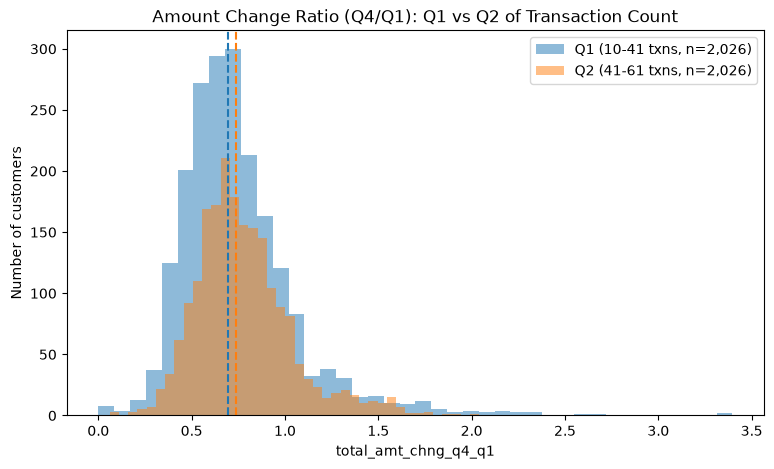

中位數|Q1: 0.694  Q2: 0.738


In [29]:
# Cell E-3(code)

# E1: total_trans_ct 分箱後, Q1(最低箱) vs Q2(次低箱) 的消費金額變化比分布 (重疊直方圖,overlaid histograms: 把兩組資料畫在同一個座標上,一眼比較兩組分布的位置與形狀差異。比並排兩張圖更容易看出「誰偏左、誰偏右、重疊多少」)

# 目的:驗證「待驗證清單 #1/#5 」的性質問題假說: 「 Q2(41-61 筆,次低箱)」含較多「消費下滑途中」的客戶,Q2 變化比分布應整體偏向低值。若假說成立,Q2 的變化比分布應整體位於較低的數值區(在圖上即:橘色整團偏在藍色這團的左側)
# 功能:把 Q1、Q2 兩組客戶各自的 total_amt_chng_q4_q1 畫在同一張直方圖上(半透明疊合),並以虛線標出兩組各自的「消費金額變化比中位數」,圖下再印出兩個中位數的精確值。

# 作法:先用布林索引從 df_e 取出 Q1 和 Q2 這兩組各自的變化比數列,再依 pyplot 四步完成:建畫布 → 繪圖(hist、axvline)→ 標註(標題、軸標、圖例)→ 顯示(plt.show)。
# 語法: 呼叫 ax 的繪圖方法: ax.hist()、ax.axvline()、ax.set_title()、 ax.set_xlabel()、ax.set_ylabel()、ax.legend()

# 判讀重點:看兩件事: (1) 兩團分布的位置:假說成立時,Q2(橘)應整體位於 Q1(藍)左側;(2) 兩條中位數虛線的相對位置:Q2 的虛線應明顯在 Q1 左邊。
# 所謂「較低」都是與 Q1 相比。

# q1 樣貌:
# 0       1.031
# 1       0.710
# 2       0.447
# 3       0.418
# 4       0.798
#         ...  
# 2021    0.294
# 2022    0.675
# 2023    0.539
# 2024    0.525
# 2025    0.466
# Name: total_amt_chng_q4_q1, Length: 2026, dtype: float64
# q2 樣貌:
# 2026    0.537
# 2027    0.467
# 2028    0.512
# 2029    0.597
# 2030    0.886
#        ...  
# 4047    0.835
# 4048    0.636
# 4049    0.738
# 4050    0.845
# 4051    0.896
# Name: total_amt_chng_q4_q1, Length: 2026, dtype: float64

q1 = df_e.loc[df_e["trans_ct_quintile"] == 1, "total_amt_chng_q4_q1"] # 取出第 1 箱客戶的消費金額變化比(2,026 筆)
q2 = df_e.loc[df_e["trans_ct_quintile"] == 2, "total_amt_chng_q4_q1"] # 取出第 2 箱客戶的消費金額變化比(2,026 筆)

fig, ax = plt.subplots(figsize=(9, 5))  # 建立 9×5 英寸的畫布(fig)與一個座標軸區(ax),之後所有繪圖動作都對 ax 做。

# ax.hist() 畫直方圖
# 把「該組變化比數值的範圍(x 軸,約 0 到 3.5)」切成 40 個等寬區間(bins=40),數出每個區間內有幾位客戶,畫成長條,長條越高代表該數值區間的人越多。
# alpha=0.5:長條半透明,兩組疊合處呈混色(圖中褐色區塊即兩組重疊的部分)。
# label:該組在圖例中顯示的名稱,f-string 的 {len(q1):,} 把人數加千分位, eg. Q1(10-41 txns, n=2,026)、Q2(41-61 txns, n=2,026)。
# y 軸直接用「人數」的前提:兩組人數相同(各 2,026),長條高度就可直接比較;若兩組人數不同,人多的組長條天生較高,就必須改用比例呈現(而非用人數的數字直接呈現)(設定參數 density=True),本圖不需要。

ax.hist(q1, bins=40, alpha=0.5, label=f"Q1 (10-41 txns, n={len(q1):,})")
ax.hist(q2, bins=40, alpha=0.5, label=f"Q2 (41-61 txns, n={len(q2):,})")


#  ax.axvline() 在指定的 x 位置畫一條垂直參考線,此處標出兩組各自的變化比中位數。
# color="C0"/"C1":matplotlib 有一組預設配色循環(C0 藍、C1 橘、C2 綠…),繪圖時依呼叫順序自動取用。上面第一次 hist 自動取了 C0(藍)、第二次取 C1(橘);此處手動指定 C0/C1,虛線顏色就與所屬組的直方圖相同,讀者不會認錯線。
# linestyle="--":虛線(與長條區隔);linewidth=1.5:線寬 1.5 點
ax.axvline(q1.median(), color="C0", linestyle="--", linewidth=1.5)
ax.axvline(q2.median(), color="C1", linestyle="--", linewidth=1.5)

ax.set_title("Amount Change Ratio (Q4/Q1): Q1 vs Q2 of Transaction Count") # 加上「圖的標題」
ax.set_xlabel("total_amt_chng_q4_q1")  # 加上「x軸標籤:消費金額變化比」
ax.set_ylabel("Number of customers")  # 加上「y 軸標籤:人數」
ax.legend()  # 加上「圖例」:右上角的小框,列出每個顏色代表哪一組(內容即 hist 的 label)
plt.show()   # 渲染顯示;plt 即 pyplot 模組本身,plt.show() 為通用的「顯示所有已畫好的圖」寫法

# 圖下另印兩組中位數的精確值:圖只能目測虛線位置,判讀與報告引用需要精確數字:「圖給形狀、數字給精確值」是繪圖輸出的標準搭配。
print(f"中位數|Q1: {q1.median():.3f}  Q2: {q2.median():.3f}")  

Cell E-4(markdown)|E1 判讀(填入 E1 實測結果並判讀)

**E1 判讀**(待驗證清單 #1、#5 性質子題)

圖的讀法:<br/>
x 軸是消費金額變化比(total_amt_chng_q4_q1;依欄位名推斷為「第四季消費金額 ÷ 第一季消費金額」,比值小於 1 代表第四季消費低於第一季。此定義為推斷等級、未經驗證也無法驗證,見 [M2-4])。<br/>
y 軸是落在各變化比數值區間的人數;藍色為 Q1 組、橘色為 Q2 組,褐色為兩組重疊處,兩條虛線為各組中位數。<br/>

- 實測:兩組分布高度相似:皆為單峰(各只有一個高峰,峰都在 0.7 附近)、右尾皆較長(高於 1.5 的零星客戶拖出右側長尾)。<br/>
  假說預測的「橘色整團位於藍色左側」的形狀並未出現。<br/>
  兩團幾乎完全重疊,且 Q2 中位數(0.738)反而略高於 Q1(0.694)。若假說為真,Q2 的虛線應明顯在左,實測卻在右,方向與預測相反;0.044 的差距也極小,代表兩組的中位數幾乎相同。<br/>
  中位數為排序後正中間客戶的值,代表該組典型客戶的水準;兩組中位數幾乎相同,即兩組的典型客戶消費變化幅度基本一致:中心無差異,加上分布形狀也幾乎重疊,構成「兩組客戶性質相同」的完整證據。<br/>
- 判定:**假說被推翻**:原假說「Q1 為長期低用量的穩定戶、Q2 為下滑途中的客戶」不成立:<br/>
  原假說若成立,分布上應看得到 Q2 整體偏低,實測則無,原假說未獲分布證據支持。<br/>
  Q2 流失率高於 Q1 的形狀維持「原因未明」記錄在案。待驗證 #1、#5 標明結案:結案的是「驗證動作已完成」,結論是「不支持原假說」。<br/>
  說明:分析的目的是「實測並呈現正確資料狀況」,不是為了「證明原假說正確」;這次驗證讓 M5 避免為一個不存在的差異設計兩套挽留方案,省下決策成本,所以「查證後推翻原假說」對決策的價值是重要的。無論查證後是推翻假說或證實假說,都對決策有價值。<br/>

- 對決策的意涵:Q1 與 Q2 在消費變化行為上無性質差異,後續階段不需要把兩箱當成兩種客群分開處理。<br/>
  M3 檢定與 M5 名單直接沿用階段 C 已定義的低活躍旗標(交易 ≤61 筆,≤61這個範圍就是 Q1+Q2 合併)作為單一客群操作 (不需把兩組分開成兩種客群操作,因為此處實證兩組客群消費變化比沒有不同,兩組客群性質相同)。階段 C 當初就是以 ≤61 筆直接畫一條界線來定義旗標(未把 Q1、Q2 分開),本次驗證確認了該定義的合理性。<br/>

- 限制:(1) 變化比只涵蓋近一年(Q4 對 Q1)的消費變化,若客戶的衰退發生在更早之前、或跨越多年緩慢發生,本欄位無法觀察到並檢視更長期的衰退軌跡。另外,因為資料沒有逐月的時間序列,也無法檢視更具體的變化軌跡;<br/>
  (2) 因此「Q2 流失率為何高於 Q1」的真正成因,在本資料中已無其他欄位可供進一步檢驗,只能如實記錄「原因未明」,並依此狀況進行後續工作。

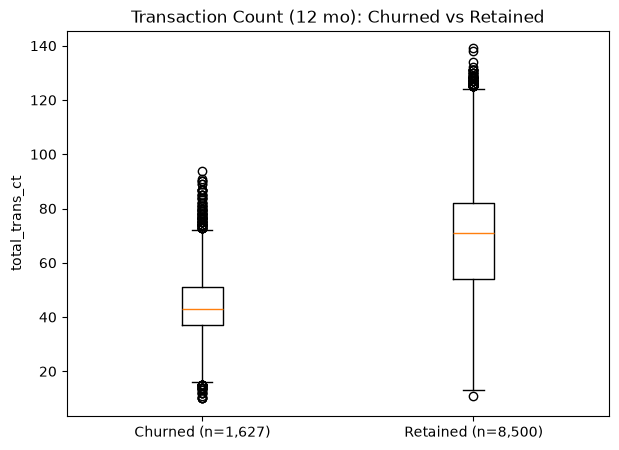

中位數|Churned: 43  Retained: 71


In [30]:
# Cell E-5 | code

# E2 流失客戶 vs 留存客戶的交易筆數分布 (箱型圖,box plot)

# 目的:切片表(H1)只呈現了各箱一個流失率數字;這張圖改用分布級的證據,直接比較「流失客戶」與「留存客戶」兩群人的交易筆數各自落在哪個範圍、兩個範圍重疊多少。重疊越少,代表交易筆數把兩群人分得越開。

# 功能:把 10,127 位客戶依是否流失分成兩組,把兩組的 total_trans_ct 畫成並排的箱型圖,圖下印出兩組中位數的精確值。
# 作法:先用布林索引從 df_e 取出兩組的交易筆數數列,再依 pyplot 四步完成:建畫布 → 繪圖(boxplot)→ 標註(標題、y 軸標籤)→ 顯示(plt.show)。

# 語法(箱型圖的讀法,本圖的判讀基礎):
#   - 箱體:該組「中間 50% 客戶」的落點範圍:箱體下緣是 25 分位數(排序後第 25% 位置的值)、上緣是 75 分位數;箱中的橫線是中位數。
#   - 鬚(whiskers):由箱體向上下延伸的兩條線,涵蓋常規範圍內的其餘客戶;超出常規範圍的值以圓點呈現,稱為離群值(outliers)。
# 註: 
#   箱型圖的通行規則(Tukey 慣例,matplotlib 預設):
#   1. IQR(四分位距)= 75 分位 − 25 分位(即箱體高度)。
#   2. 常規範圍 = 25 分位 − 1.5×IQR 到 75 分位 + 1.5×IQR。
#   3. 鬚頂端的橫線 = 常規範圍內「實際存在的最大一筆資料」的位置;鬚底端同理(範圍內實際最小值)。鬚刻意不延伸到最遠的資料:常規範圍外的每一筆資料,改以圓點單獨標出,稱為離群值。
#   4. 以流失組驗證:IQR = 51−37 = 14,1.5×IQR = 21,常規範圍 16–72。鬚頂即 72 附近,72–94 的資料全部成為上側離群值的點。
#   5. 離群值是「離中間 50% 異常遠」的提醒,值得單獨標出來檢視。慣例上是這樣訂定離群值的門檻,但不是判定資料有錯,只是提醒「這些值特別遠」。

# 判讀重點: (這張圖的完整事實:兩組的主體有錯開、但尾端有部分重疊)
#   1. 看兩組的「箱體」(主體:各組的中間 50% 客戶)是否重疊,本例無重疊。
#   注意:比較的是箱體,不是整組資料的全範圍。
#   若流失組箱體(其中間 50% 客戶的範圍)整段位於留存組箱體(其中間 50% 客戶的範圍)之下,表示「兩箱體不重疊」,代表兩組「各自最典型的半數客戶」在交易筆數上完全錯開。表示「兩組在交易筆數上的差異」來自主體(大多數客戶本身不同),並非少數極端客戶造成的 (eg.「留存組某個極端客戶交易筆數超過500筆,其他客戶交易筆數與流失組差不多」這樣的情形不存在,若是該情形,兩組平均數會有差距,但箱體會重疊,本圖箱體不重疊,排除了這種可能)。這使 H1 切片所見的「筆數與流失率的強關聯」可確認為資料中大多數客戶的普遍現象。

#   2. 看兩組的「尾端」是否重疊,本例有重疊: (「流失組交易最多的四分之一」和「留存組交易最少的四分之一」有重疊)

#   3. 本圖事實:兩組的「主體錯開、尾端重疊」。主體: 50%。尾端:「流失組交易最多的四分之一」和「留存組交易最少的四分之一」。
#   4. 注意: 使用此變數(交易筆數的數值)作為「判斷流失或留存的」的規則時, 「尾端的重疊部分」就是誤判的來源。
#      舉例: 流失組 75 分位 ≈51,表示「流失組交易最多的四分之一」是筆數 51 到 94 的人;留存組 25 分位 ≈54,「留存組交易最少的四分之一」是筆數 11 到 54 的人。這兩段範圍(51–94 和 11–54)有重疊, 所以「交易筆數 52 筆的客戶可能是流失組也可能是留存組」,「這個客戶是流失或留存」就可能發生誤判。
#   5. 小結: 尾端重疊的部分越少, 用此變數(交易筆數)作為「判斷流失或留存的」的規則時, 誤判也會越少。



# 註:左側數字為該列在 df_e 的列索引(布林索引保留原索引,故不連續);索引僅為位置編號,無業務含義。
# churned 這個 Series 的樣貌:
# 0      10
# 1      10
# 2      10
# 3      10
# 4      11
#       ..
# 8962   90
# 9000   90
# 9009   90
# 9068   91
# 9231   94
# Name: total_trans_ct, Length: 1627, dtype: int64

# retained 這個 Series 的樣貌:
# 5        11
# 10       13
# 12       13
# 23       14
# 31       15
#       ... 
# 10122   131
# 10123   132
# 10124   134
# 10125   138
# 10126   139
# Name: total_trans_ct, Length: 8500, dtype: int64

churned = df_e.loc[df_e["is_churned"], "total_trans_ct"]    # 取出流失客戶的交易筆數(is_churned 為 True 的列)
retained = df_e.loc[~df_e["is_churned"], "total_trans_ct"]  # 取出留存客戶的交易筆數(is_churned 為 False 的列)(~ 為布林反轉,True 變 False)

fig, ax = plt.subplots(figsize=(7, 5))  # 建立 7×5 英寸的畫布(fig)與座標軸區(ax)

# boxplot 接收一個 list(清單),list 在這裡裝兩個 Pandas Series: churned 和 retained 這兩個 Series。
# Pandas 的 Series (數列): 就是單獨一欄資料(一維陣列),左邊是索引(Index)、右邊是資料內容(Values),以本處的 churned 這個 Series 為例,可參上方印出樣貌,churned 這一整欄總共有 1,627 筆資料。
# list 裡放幾個 Series 就並排畫幾箱,此處 list 裡有兩個 Series,所以畫兩個箱。

# tick_labels:指定 x 軸兩個位置的組名 (matplotlib 3.9 起, boxplot() 的參數名由 labels 改為 tick_labels;舊版若報錯,改回 labels= 即可)。
ax.boxplot([churned, retained], tick_labels=[f"Churned (n={len(churned):,})",
                                             f"Retained (n={len(retained):,})"])


ax.set_title("Transaction Count (12 mo): Churned vs Retained")  # 圖標題:近 12 月交易筆數,流失 vs 留存
ax.set_ylabel("total_trans_ct")  # y 軸標籤:交易筆數(箱型圖的數值在 y 軸,x 軸是組別:流失組 vs 留存組)
plt.show()  # 渲染顯示

# 下方印出中位數精確值: 「圖給形狀、數字給精確值」,中位數的精確值供判讀與報告引用
print(f"中位數|Churned: {churned.median():.0f}  Retained: {retained.median():.0f}")

Cell E-6(markdown)|E2 判讀(填入 E2 實測結果並判讀)

**E2 判讀**

本 E2 圖(與 E3 圖)的動機:<br/>
E1 是為了驗證一個特定假說; <br/>
E2、E3 則是「行為輪廓」任務本身:「流失客戶在流失前的行為特徵長什麼樣」。<br/>
切片表只能給各客群的流失率數字,但無法回答特定欄位的數值「長什麼樣」,分布圖才能看出。<br/>
E2 選擇觀察交易筆數,因為它是全案最強的單一訊號(H1);E3 選擇觀察交易金額,因為它是 M3 預定的檢定對象,需要先確認分布形狀。<br/>

圖的讀法:<br/>
y 軸是近 12 個月交易筆數的數值;左箱為流失客戶(1,627 人)、右箱為留存客戶(8,500 人);<br/>
每個箱體涵蓋該組中間 50% 的客戶(下緣 25 分位、上緣 75 分位),箱中橫線為中位數,箱外圓點為離群值。<br/>

- 實測:流失組的交易筆數中位數 43、留存組的交易筆數中位數 71。<br/>
  **兩個箱體幾乎不重疊**: (本圖完整事實:主體錯開、尾端重疊)<br/>
  流失組的箱體(37–51)整段位於留存組的箱體(54–82)之下,兩組「各自中間 50% 的典型客戶」在交易筆數上完全錯開。<br/>
  注意:錯開的是箱體(主體),不是全部資料都錯開:<br/>
  
  流失組的高筆數尾端(51–94)與留存組的低筆數區段(11-54)仍有重疊,重疊區的客戶可能發生誤判。(詳細說明參考 Cell E-5 判讀重點)<br/>
  
  主體錯開的意義:兩組在交易筆數上的差異來自「大多數人本身不同」,不是少數極端值造成的。因此可確認, H1 切片所見的「筆數與流失率的強關聯」為資料中大多數客戶的普遍現象(大多數,非全體,尾端重疊區即是例外)。<br/>
  

- 從圖到規則:箱型圖負責呈現「這個變數分得開兩群人」,但它本身不產生規則;實務上會把變數轉成一條明確的門檻,門檻位置取自流失率的斷點,本案的門檻位置設定為階段 B 實測的 61 筆(41–61 筆整箱流失率仍達 37%, 61 筆起驟降至 7%),也就是階段 C 的低活躍旗標。<br/>
  
  誤判無法完全避免:尾端重疊區的客戶單看筆數會被分錯邊:(1)實際流失但筆數高於門檻者被漏掉、(2)實際留存但筆數低於門檻者被誤圈。<br/>
  這兩類錯誤已由 C3-b 量化:名單精準度 47% ➡ 代表誤圈約 53% ; 流失者覆蓋率 72% ➡ 代表漏抓 28%。<br/>
  (註:流失者覆蓋率 = 名單圈住的流失者 ÷ 全體流失者(1,627 人); 名單精準度 = 名單圈住的流失者 ÷ 名單規模。)<br/>
  
  分工:(1)圖負責發現(視覺化,看出變數分得開流失組和留存組)、(2)門檻負責可執行(條件明確,可寫入系統自動篩選)、(3)C3-b 的兩個指標負責呈現錯誤率。<br/>
  
  小結:大部分客戶能分對邊、分錯邊的也可以量化。(兩箱體不重疊,表示用一條線把客戶切兩半,就能讓大部分人被分對邊。接著再用精準度與覆蓋率量化錯誤率)<br/>


- 判定:「E2 測出的分布級證據」與「H1 切片」結論一致(交易筆數越低、流失率越高)。<br/>
  稱「交易筆數」為全案把流失與留存「分得最開」的「變數」,依據有二:<br/>
  (1) 切片級: 其 diff_pp(+15.4 ~ +21.2) 為全案單變數之最;<br/>
  (2) 分布級: 本節繪製分布圖的兩個變數(E2和E3)中,只有E2的兩箱體不重疊(E3交易金額的兩箱體仍明顯重疊);其餘行為變數的數值多為 0–6 的低基數整數(eg.客戶與銀行的聯繫次數),不適用箱型圖。其餘行為變數雖未繪製箱型圖,其區分力已由階段 B 切片表的 diff_pp 呈現(最高者為不活躍月數 +13.8),均不及交易筆數(+15.4 ~ +21.2)。<br/>
  
  能把流失與留存「分得最開」,其實務效果是「用這個變數做規則,誤判會最少」,因此:<br/>
  (1) M5 預警指標的第一優先:監控報表若只放一個數字,就放交易筆數;(2) 預期會是 M4 特徵重要性第一名:模型的工作就是分開兩群人,分得開的變數貢獻自然大(此為預期,後續由 M4 實測);(3) M8 向決策者溝通的首選圖:「典型流失客戶(37–51 筆)整段低於典型留存客戶(54–82 筆)」,不需高深統計背景即可看懂。<br/>

- 對決策的意涵:<br/>
(1) 對 M8:向決策者呈現流失客群的樣貌時,這張圖一眼就能傳達「流失客戶的典型交易量(中間 50%:37–51 筆)整段低於留存客戶的典型交易量(54–82 筆)」,任何背景都能看懂,故列為簡報候選主圖。<br/>
(2) 對 M4:模型訓練後會產出「各特徵對預測的貢獻排序」(特徵重要性,M4 說明);一個單獨就能把兩群人分開的變數,可預期「此變數對預測的貢獻排序」會排在前幾名(此為依 E2 結果做的預期,實際排序由 M4 實測)。<br/>


- 限制:本欄記錄的是「快照時點往回看 12 個月」的累計交易筆數,資料裡沒有這些交易發生的先後時間,所以無法判斷是「交易先變少、之後才流失」(交易量是預警訊號),
  還是「客戶先決定離開、停用卡片使累計筆數變少」(交易量只是流失的結果)。這兩種情況在這張圖上長相是一樣的 ([M2-5] 說明的 H6 限制也是此類型的限制),所以此圖仍有其判斷上的限制。

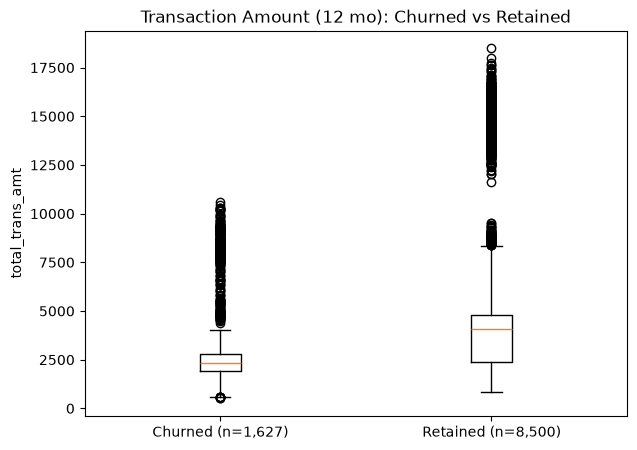

中位數|Churned: 2,329  Retained: 4,100
平均數|Churned: 3,095  Retained: 4,655


In [31]:
# Cell E-7(code)

# E3:流失客戶 vs 留存客戶的「交易金額分布」(箱型圖)

# 目的:透過箱型圖看出「total_trans_amt 的「右偏」分布形狀」。此欄是 M3 預定的 Mann-Whitney 檢定對象:右偏資料不適合用平均數比較(平均數會被少數高消費客戶拉高,偏離多數人的實況),這張圖就是 M3「為何比名次、不比平均」這個方法選擇的視覺佐證。

# 功能:把兩組的 total_trans_amt 畫成並排箱型圖;圖下同時印出兩組的中位數與平均數:兩者的落差即「平均數被高值拉高」的數字證據。
# 作法:同 E-5 的四步流程 (先用布林索引從 df_e 取出兩組的交易金額數列,再依 pyplot 四步完成:建畫布 → 繪圖(boxplot)→ 標註(標題、y 軸標籤)→ 顯示(plt.show)),僅資料欄位換成 total_trans_amt,並多印一行平均數。

# 判讀重點:資料右偏的三個視覺特徵 : (1) 離群值集中在箱體上側; (2) 上鬚明顯長於下鬚; (3)「平均數」大於「中位數」(由 print 的兩行數字比對)。
# 若三個特徵都存在,依實務慣例即可判定資料分布右偏(此為目視判定,已足供本案使用;更嚴格的做法是計算偏態係數,去量化偏斜程度,本案不需要。因為:全案用到「右偏」這個事實的決策只有兩個:分箱採等量分箱([M2-2])、檢定採非參數方法(M3)。兩者都只需要「是否右偏」的定性判斷;偏態係數多提供的「偏斜多少」的精確數值,不會改變任何本案後續決策,多算只是增加負擔而無決策效益。)

# 註:左側數字為該列在 df_e 的列索引(布林索引保留原索引,故不連續);索引僅為位置編號,無業務含義。
# churned_amt 這個 Series 的樣貌:
# 0        646.0
# 1        530.0
# 2        741.0
# 3        695.0
# 4        678.0
#          ...  
# 8962    8038.0
# 9000    8607.0
# 9009    7991.0
# 9068    8173.0
# 9231    8600.0
# Name: total_trans_amt, Length: 1627, dtype: float64

# retained_amt 這個 Series 的樣貌:
# 5          975.0
# 10        1064.0
# 12        1122.0
# 23        1413.0
# 31        1893.0
#           ...   
# 10122    15277.0
# 10123    12920.0
# 10124    14880.0
# 10125    13939.0
# 10126    13085.0
# Name: total_trans_amt, Length: 8500, dtype: float64

churned_amt = df_e.loc[df_e["is_churned"], "total_trans_amt"]    # 流失客戶的交易金額 (is_churned 為 True 的列)
retained_amt = df_e.loc[~df_e["is_churned"], "total_trans_amt"]  # 留存客戶的交易金額 (is_churned 為 False 的列)(~ 為布林反轉,True 變 False)

fig, ax = plt.subplots(figsize=(7, 5)) # 建立 7×5 英寸的畫布(fig)與座標軸區(ax)

# boxplot 接收一個 list(清單),list 在這裡裝兩個 Pandas Series: churned_amt 和 retained_amt 這兩個 Series。
# Pandas 的 Series (數列): 就是單獨一欄資料(一維陣列),左邊是索引(Index)、右邊是資料內容(Values),以本處的 churned_amt 這個 Series 為例,可參上方印出樣貌,churned_amt 這一整欄總共有 1,627 筆資料。
# list 裡放幾個 Series 就並排畫幾箱,此處 list 裡有兩個 Series,所以畫兩個箱。
# tick_labels:指定 x 軸兩個位置的組名 (matplotlib 3.9 起, boxplot() 的參數名由 labels 改為 tick_labels;舊版若報錯,改回 labels= 即可)。
ax.boxplot([churned_amt, retained_amt], tick_labels=[f"Churned (n={len(churned_amt):,})",
                                                     f"Retained (n={len(retained_amt):,})"])

ax.set_title("Transaction Amount (12 mo): Churned vs Retained")  # 圖標題:近 12 個月的交易金額,流失 vs 留存
ax.set_ylabel("total_trans_amt")  # y 軸標籤:交易金額 (箱型圖的數值在 y 軸,x 軸是組別:流失組 vs 留存組)

plt.show()  # 渲染顯示

# 下方同時印出「.median()中位數」與「.mean()平均數」 (圖給形狀、數字給精確值,供判讀與報告引用):
# 中位數與平均數的差距,是「資料右偏」的數值證據: 具有右偏屬性的資料,可看出整份資料的「平均數」 > 整份資料的「中位數」。
print(f"中位數|Churned: {churned_amt.median():,.0f}  Retained: {retained_amt.median():,.0f}")
print(f"平均數|Churned: {churned_amt.mean():,.0f}  Retained: {retained_amt.mean():,.0f}")

Cell E-8(markdown)|E3 判讀(填入 E3 實測結果並判讀)

**E3 判讀**

圖的讀法:y 軸是近 12 個月交易金額;左箱為流失客戶、右箱為留存客戶;箱體、中位數線、離群值的讀法同 E2。

- 實測:流失組中位數 2,329、留存組中位數 4,100 : 留存客戶的典型消費金額約為流失客戶的 1.8 倍。
  - 右偏的三個視覺特徵都存在,依實務慣例即可判定分布右偏(此為目視判定,已足供本案使用;更嚴格的做法是計算偏態係數量化偏斜程度,本案不需要):
  (1) 兩組的離群值全部集中在箱體上側;(2) 上鬚明顯長於下鬚;(3) 兩組的平均數都高於中位數(流失組 3,095 vs 2,329、留存組 4,655 vs 4,100):平均數被少數高消費客戶拉高,偏離了各組多數客戶的實際水準(因:算術平均對極大值敏感,任何右偏資料皆會有出現此統計性質)。
  - 另外,留存組上側的離群值呈現明顯的群集(約 11,500 以上另成一團):這是高消費客群的聚集,屬分布特徵而非資料異常(依據:數值落在稽核 [D] 確認的合理範圍內;「消費金額右偏」與「高消費族群的存在」,是金融消費資料的常態)。

- 判定:資料右偏如 M1 稽核 [D] 所預期地呈現(稽核當時由「平均數遠大於中位數」判定金額類欄位右偏,本圖以完整分布確認)。

- 對決策的意涵:分布右偏時,用平均數比較兩組會被少數高值客戶帶偏: 
  本圖形狀提供 M3 選擇檢定方法的依據: 
  M3 對本欄採 Mann-Whitney 檢定: 這個檢定比較的是兩組數值的名次(全體排序後,位在第幾名),不是比較「金額本身」:一位客戶的金額再極端,也只占一個名次,無法左右整組的比較結果;平均數則會被少數極高金額(eg.金額數值特別大的客戶,如:上萬元的高消費客戶)直接影響。因此,右偏資料需改比名次,而非只比金額。
  檢定方法的細節於 M3 說明。

- 限制:同 E2。本欄記錄的是「快照時點往回看 12 個月」的累計交易金額,快照資料無法觀察「消費金額下降」與「流失決定」的先後順序:
  資料裡沒有這些交易發生的先後時間,所以無法判斷是「交易金額先變少、之後才流失」(交易金額數字是預警訊號),
  還是「客戶先決定離開、停用卡片使累計交易金額變少」(交易金額數字只是流失的結果)。這兩種情況在這張圖上長相是一樣的 ([M2-5] 說明的 H6 限制也是此類型的限制),所以此圖仍有其判斷上的限制。

Cell E-9(markdown)|M2 收尾:待驗證事項清單(v3)

## M2 收尾|待驗證事項清單(v3)

**定位**:本表整合階段 B 小結(v1,Cell 37)、階段 C 小結(v2,Cell C-13)與階段 D/E 的判讀,是 M2 交付後續模組(M3–M8)的唯一對照表。後續每個模組開工時先依「交辦階段」欄篩出本模組承接的項目,收尾時回填狀態。編號沿用 v1/v2,不重編,以便回溯。

**已結案項目**(於 M2 內完成驗證,列出以保留證據,後續不需再處理):

| # | 事項 | 驗證結果 | 依據 |
|---|---|---|---|
| 1 | H1 的 Q2>Q1 預期外形狀:「衰退方向比活躍水位更能預警」假說 | ✅ 假說被推翻:Q1(10–41 筆)與 Q2(41–61 筆)的消費變化比分布高度重疊,中位數 0.694 vs 0.738;兩箱為同一性質客群,M3/M5 以低活躍旗標(≤61 筆)合併處理;Q2 流失率高於 Q1 的成因,本資料無其他欄位可查,列為原因未明 | notebook 02 Cell E-3/E-4(E1 判讀) |
| 2 | 零動用訊號的精確 diff_pp 幅度(0 vs >0 二分重驗) | ✅ n=2,470、流失率 36.15%、diff_pp +20.08;清單 v2 起一律引用此數字 | Cell C-3/C-4(C1 判讀) |
| 3 | 活躍水位類訊號的名單重疊規模 | ✅ 四個正式旗標名單合計 10,410 人次,去重後 7,292 人(重複 30%);聯集占全體 72%,「至少命中一旗標」不具篩選功能 | Cell C-7/C-8(C3-a 判讀) |
| 4 | 低額度訊號的獨立性(是否為收入效應的影子) | ✅ 控制收入後六組組內差距全部同向(+3.1 ~ +12.9 pp),低額度為獨立訊號;升級進候選洞察清單 v2(觀察層),列入 M4 候選特徵 | Cell C-11/C-12(C4 判讀) |
| 5 | 消費下滑(方向類訊號)與低活躍(水位類訊號)的重疊程度與性質 | ✅ 人數重疊 60%(1,211 / 2,012);性質問題由 E1 結案:Q1/Q2 為同一性質客群 | Cell C-8 第四點、Cell E-4 |
| 10 | avg_utilization_ratio 定義驗證(= total_revolving_bal / credit_limit?) | ✅ mismatch = 0,定義實證成立,證據等級升為「已驗證」;total_amt_chng_q4_q1 無法驗證,維持「推斷」 | Cell 35.1/35.2、[M2-4] |

**交辦後續模組的項目**(依交辦階段排列):

| # | 事項 | 為什麼要做 | 交辦階段 | 依據 |
|---|---|---|---|---|
| 12 | 事後發現二則(Doctorate 21.06%、Unknown × 低額度 28.06%)是否進 M3 檢定 | 事後發現的解讀強度受 [M2-1] 規範;若進檢定,報告須明示非事前假設 | M3 | Cell 11、Cell C-12 處置 3、[M2-1] |
| 15 | H6 的因果方向未定:聯繫多是流失前兆,或是已決定流失者辦理註銷、爭議所產生的聯繫,快照資料無法區分 | 影響「聯繫次數」作為提前預警的價值;M3 的 H6 檢定報告與 M8 簡報須明示「風險標記,非提前預警」 | M3 / M8 | Cell 21(H6 判讀)、[M2-5] |
| 16 | H8 性別差距(組間差距 2.74 個百分點)作為「統計顯著 vs 實務顯著」的示範案例 | 全案「檢定通過 ≠ 該採取行動」的示範;M3 對性別做檢定並計算效果量,兩者並列呈現 | M3 | Cell 9(H8 判讀)、清單 v2 #10 |
| 6 | 建模時評估納入交互項(low_activity 分別乘上零動用 / 淺關係 / 高聯繫) | C2 效果分解:同一訊號在低活躍與活躍正常子群內的效果相差 2.4–15 倍,模型需能表達此結構 | M4 | Cell C-6(C2 判讀)、[M2-8] |
| 7 | 檢查旗標特徵之間的相關性對迴歸係數穩定性的影響 | 共線性:兩個高度相關的變數放入同一迴歸模型,模型難以分辨影響歸屬,係數估計不穩定;由 C3-a 的高度重疊可預期旗標轉為特徵後彼此高度相關 | M4 | Cell C-8(C3-a 判讀) |
| 8 | M4 模型評估報告必須附上與 C3-b 命中數分層基準的成績比較 | 命中 ≥3 名單精準度已達 83%,未用任何模型;模型須明顯勝過此基準才有引入的理由 | M4 | Cell C-10(C3-b 判讀)、[M2-9] |
| 18 | tenure 進模型的兩項注意:(1) 與 customer_age 相關係數 0.7889,須二擇一;(2) tenure=36 單值聚集 2,463 人(占 25–36 箱 45%),使其有效區分力低於值域表面所示;年齡 × tenure 的交互作用單變數切片無法驗證,若任一進模型由模型評估 | 避免共線導致係數不穩,並避免把 tenure 的低重要性誤讀為「年資不重要」 | M4 | Cell 31(年齡判讀)、Cell D-4(H9 判讀)、sql/03_cohort.sql [D1-補]、[M1-5] |
| 9 | 挽留名單門檻(命中旗標數 ≥2 或 ≥3)依預算與成本效益定案 | C3-b 試算:≥2 覆蓋 72% / 精準 47%,≥3 覆蓋 29% / 精準 83%,兩指標無法兩全,屬商業決策 | M5 | Cell C-10(C3-b 判讀)、[M2-9] |
| 10-a | 高聯繫預警線位置(現為 ≥4 次的工作預設值)依成本效益定案 | 門檻降至 ≥3 次名單自 1,622 人增至 5,002 人、誤報明顯;最終位置取決於挽留預算、單位成本與客戶價值 | M5 | Cell 21 註、Cell C-1 旗標表、[M2-5] |
| 17 | H3 消費變化比的門檻位置:0.604 僅為五分位箱界,非精確門檻 | 若 M5 採「變化比 < X 即示警」規則,X 需要更準的定位:對 0.4–0.8 區間做更細分箱(如十分位),觀察流失率跳升的確切位置 | M5 | Cell 27(H3 判讀) |
| 11 | 「調高額度」不得直接列為挽留手段;若要採用,須經實驗驗證 | 低額度與流失的機制未定:(a) 額度造成使用不便,或 (b) 額度只是關係深度的痕跡;若為 (b),調額是處理痕跡而非成因,唯有 M6 實驗能驗證 | M5 / M6 | Cell C-12 第二點 |
| 13 | mart 層匯出:依 M8 儀表板設計定案後,一次匯出 data/processed/ 的 CSV | 下游需求(儀表板要呈現什麼)未定前匯出無驗收標準;只是延後,不是取消 | M8 | [M2-13] |
| 14 | Excel 樞紐分析重現:以樞紐表重現一張儀表板選用的切片,驗證與 SQL 數字一致,產出 churn_pivot_summary.xlsx,README 技術棧列入 Excel | 展示跨工具重現同一分析並核對數字一致的能力;與 #13 一併完成 | M8 | [M2-14] |

註一:v2 的 #10「高聯繫預警線位置」與 v1 的 #10「utilization 定義驗證」編號重複,前者於本表改編為 #10-a,後者維持 #10。<br/>
註二:本表未列入的 v1/v2 條目皆已併入其他編號:v1 #9(Doctorate)併入 #12。<br/>

**清單演變紀錄**:v1(階段 B 小結,11 條)→ v2(階段 C 小結:#1–#5 更新狀態,新增 #6–#14;v1 的 #6/#7/#8/#11 於 v2 漏列)→ v3(本表:補回漏列四條為 #15–#18,#18 併入階段 D 發現的 tenure=36 聚集;#1、#5 依階段 E 結案;#10 編號衝突以 #10-a 區分)。<br/>

**M3 開工檢核**(進入 M3 前先核對):承接 #12、#15、#16;M3 收尾時回填三者狀態並將本表複製至 notebook 03 開頭作為承接依據。